# Volve Oil Production Data Science Project
## Notebook 03: Predictive Model Development and Validation

### Purpose

This notebook develops and evaluates predictive approaches for next-month oil production using the forecasting problem established in Notebook 02.

The primary task is:

**Using information available up to and including month \(t\), predict the realised oil production volume of the same producer well in month \(t+1\).**

Model development follows a strictly chronological framework.

Observations before April 2015 are used for model development, while observations from April 2015 onward form an untouched final holdout set. Model comparison and tuning within the development period will use time-aware validation rather than random train-test splitting.

The modelling process begins with simple forecasting baselines before progressing to statistical and machine learning approaches. More complex models will only be considered useful if they improve upon the simpler baselines under the same chronological evaluation framework.

Performance will be evaluated both across the pooled multi-well dataset and separately by producer well.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
import sklearn


print(
    "SciPy version:",
    scipy.__version__
)

print(
    "scikit-learn version:",
    sklearn.__version__
)

SciPy version: 1.18.0
scikit-learn version: 1.9.0


In [2]:
PROJECT_ROOT = Path(
    r"F:\DataScience_Projects\Volve_Oil_Production"
)


PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


MODEL_READY_PATH = (
    PROCESSED_DATA_DIR
    / "02_modeling_ready_monthly_forecast.csv"
)


DEVELOPMENT_PATH = (
    PROCESSED_DATA_DIR
    / "02_development_pre_2015_04.csv"
)


FINAL_HOLDOUT_PATH = (
    PROCESSED_DATA_DIR
    / "02_final_holdout_2015_04_onward.csv"
)


MODEL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "03_model_development"
)


MODEL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Model-ready dataset exists:",
    MODEL_READY_PATH.exists()
)

print(
    "Development dataset exists:",
    DEVELOPMENT_PATH.exists()
)

print(
    "Final holdout dataset exists:",
    FINAL_HOLDOUT_PATH.exists()
)

print(
    "Notebook 03 output directory:",
    MODEL_OUTPUT_DIR
)

Model-ready dataset exists: True
Development dataset exists: True
Final holdout dataset exists: True
Notebook 03 output directory: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development


## 1. Modelling Dataset Verification

The processed forecasting datasets generated in Notebook 02 are loaded without modifying their chronological structure.

Three datasets are retained:

- the complete modelling-ready forecasting dataset;
- the pre-April-2015 development dataset;
- the April-2015-onward final holdout dataset.

The final holdout will not be used for model selection or hyperparameter tuning.

In [3]:
model_ready_df = pd.read_csv(
    MODEL_READY_PATH,
    parse_dates=["DATE"]
)


development_df = pd.read_csv(
    DEVELOPMENT_PATH,
    parse_dates=["DATE"]
)


final_holdout_df = pd.read_csv(
    FINAL_HOLDOUT_PATH,
    parse_dates=["DATE"]
)


print(
    "Complete modelling-ready observations:",
    len(model_ready_df)
)

print(
    "Development observations:",
    len(development_df)
)

print(
    "Final holdout observations:",
    len(final_holdout_df)
)

print(
    "Development coverage:",
    development_df["DATE"].min(),
    "to",
    development_df["DATE"].max()
)

print(
    "Final holdout coverage:",
    final_holdout_df["DATE"].min(),
    "to",
    final_holdout_df["DATE"].max()
)

Complete modelling-ready observations: 300
Development observations: 215
Final holdout observations: 80
Development coverage: 2008-02-01 00:00:00 to 2015-03-01 00:00:00
Final holdout coverage: 2015-04-01 00:00:00 to 2016-08-01 00:00:00


In [4]:
FINAL_HOLDOUT_CUTOFF = pd.Timestamp(
    "2015-04-01"
)


assert (
    development_df["DATE"]
    < FINAL_HOLDOUT_CUTOFF
).all()


assert (
    final_holdout_df["DATE"]
    >= FINAL_HOLDOUT_CUTOFF
).all()


assert (
    development_df[
        "target_next_month_oil_volume"
    ]
    .notna()
    .all()
)


assert (
    final_holdout_df[
        "target_next_month_oil_volume"
    ]
    .notna()
    .all()
)


assert (
    development_df["DATE"].max()
    <
    final_holdout_df["DATE"].min()
)


print(
    "PASS: development and final holdout "
    "remain chronologically separated."
)

print(
    "PASS: target values are available "
    "throughout both modelling datasets."
)

PASS: development and final holdout remain chronologically separated.
PASS: target values are available throughout both modelling datasets.


## 2. Naive Persistence Baseline

A persistence forecast is used as the first benchmark for the predictive system.

For each producer well, the forecast assumes that next-month oil production will be equal to the oil production observed in the current month:

\[
\hat{y}_{t+1} = y_t
\]

This baseline requires no model fitting and uses only information available at the forecasting origin.

It provides a strong reference for short-horizon production forecasting because adjacent monthly production values may exhibit temporal persistence.

More advanced models will only be considered useful if they improve upon this benchmark under the same chronological evaluation framework.

The final April-2015-onward holdout set remains untouched at this stage.

In [5]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def calculate_regression_metrics(
    actual,
    predicted
):
    """
    Calculate regression metrics used throughout
    Notebook 03.
    """

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


print(
    "Regression metric function ready."
)

Regression metric function ready.


In [6]:
persistence_development_df = (
    development_df
    .copy()
)


assert (
    persistence_development_df[
        "oil_volume"
    ]
    .notna()
    .all()
)


assert (
    persistence_development_df[
        "target_next_month_oil_volume"
    ]
    .notna()
    .all()
)


persistence_development_df[
    "persistence_prediction"
] = (
    persistence_development_df[
        "oil_volume"
    ]
)


persistence_development_df[
    "persistence_error"
] = (
    persistence_development_df[
        "target_next_month_oil_volume"
    ]
    -
    persistence_development_df[
        "persistence_prediction"
    ]
)


persistence_development_df[
    "absolute_error"
] = (
    persistence_development_df[
        "persistence_error"
    ]
    .abs()
)


print(
    "Persistence predictions created:",
    len(
        persistence_development_df
    )
)


display(
    persistence_development_df[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            "target_next_month_oil_volume",
            "persistence_prediction",
            "persistence_error"
        ]
    ]
    .head(12)
)

Persistence predictions created: 215


,NPD_WELL_BORE_NAME,DATE,oil_volume,target_next_month_oil_volume,persistence_prediction,persistence_error
0,15/9-F-1 C,2014-04-01,11142.47,24901.95,11142.47,13759.48
1,15/9-F-1 C,2014-05-01,24901.95,19617.76,24901.95,-5284.19
2,15/9-F-1 C,2014-06-01,19617.76,15085.68,19617.76,-4532.08
3,15/9-F-1 C,2014-07-01,15085.68,6970.43,15085.68,-8115.25
4,15/9-F-1 C,2014-08-01,6970.43,9168.43,6970.43,2198.00
5,15/9-F-1 C,2014-09-01,9168.43,9468.06,9168.43,299.63
6,15/9-F-1 C,2014-10-01,9468.06,6710.33,9468.06,-2757.73
7,15/9-F-1 C,2014-11-01,6710.33,120.29,6710.33,-6590.04
8,15/9-F-1 C,2014-12-01,120.29,10875.53,120.29,10755.24
9,15/9-F-1 C,2015-01-01,10875.53,9586.64,10875.53,-1288.89


In [7]:
persistence_metrics = (
    calculate_regression_metrics(
        persistence_development_df[
            "target_next_month_oil_volume"
        ],

        persistence_development_df[
            "persistence_prediction"
        ]
    )
)


persistence_overall_summary = pd.DataFrame({
    "model": [
        "Naive Persistence"
    ],

    "observations": [
        len(
            persistence_development_df
        )
    ],

    "MAE": [
        persistence_metrics[
            "MAE"
        ]
    ],

    "RMSE": [
        persistence_metrics[
            "RMSE"
        ]
    ],

    "R2": [
        persistence_metrics[
            "R2"
        ]
    ]
})


persistence_overall_summary[
    [
        "MAE",
        "RMSE",
        "R2"
    ]
] = (
    persistence_overall_summary[
        [
            "MAE",
            "RMSE",
            "R2"
        ]
    ]
    .round(4)
)


display(
    persistence_overall_summary
)

,model,observations,MAE,RMSE,R2
0,Naive Persistence,215,9199.7977,14674.1155,0.8678


In [8]:
persistence_well_rows = []


for well_name, group in (
    persistence_development_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    metrics = (
        calculate_regression_metrics(
            group[
                "target_next_month_oil_volume"
            ],

            group[
                "persistence_prediction"
            ]
        )
    )


    persistence_well_rows.append({
        "well":
            well_name,

        "observations":
            len(group),

        "target_mean":
            group[
                "target_next_month_oil_volume"
            ].mean(),

        "MAE":
            metrics["MAE"],

        "RMSE":
            metrics["RMSE"],

        "R2":
            metrics["R2"]
    })


persistence_well_summary = (
    pd.DataFrame(
        persistence_well_rows
    )
)


persistence_well_summary[
    [
        "target_mean",
        "MAE",
        "RMSE",
        "R2"
    ]
] = (
    persistence_well_summary[
        [
            "target_mean",
            "MAE",
            "RMSE",
            "R2"
        ]
    ]
    .round(4)
)


display(
    persistence_well_summary
)

,well,observations,target_mean,MAE,RMSE,R2
0,15/9-F-1 C,12,10192.3750,5103.5825,6419.3798,0.0368
1,15/9-F-11,21,31818.1786,7075.2286,9925.4602,-0.3732
2,15/9-F-12,86,50777.2780,11093.1719,17160.4427,0.8784
3,15/9-F-14,81,47179.9937,9768.7027,15041.2820,0.8103
4,15/9-F-15 D,15,5427.4240,1523.7340,2334.7474,-0.4214


In [9]:
largest_persistence_errors = (
    persistence_development_df[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            "target_next_month_oil_volume",
            "persistence_prediction",
            "persistence_error",
            "absolute_error"
        ]
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)


display(
    largest_persistence_errors
)

,NPD_WELL_BORE_NAME,DATE,oil_volume,target_next_month_oil_volume,persistence_prediction,persistence_error,absolute_error
46,15/9-F-12,2009-03-01,92958.71,150955.68,92958.71,57996.97,57996.97
41,15/9-F-12,2008-10-01,94357.23,145915.56,94357.23,51558.33,51558.33
35,15/9-F-12,2008-04-01,74532.45,125478.56,74532.45,50946.11,50946.11
131,15/9-F-14,2009-07-01,64871.82,112493.50,64871.82,47621.68,47621.68
120,15/9-F-14,2008-08-01,67621.20,114596.26,67621.20,46975.06,46975.06
56,15/9-F-12,2010-01-01,149658.83,103026.00,149658.83,-46632.83,46632.83
122,15/9-F-14,2008-10-01,142817.06,104409.61,142817.06,-38407.45,38407.45
52,15/9-F-12,2009-09-01,90098.89,126939.65,90098.89,36840.76,36840.76
33,15/9-F-12,2008-02-01,49091.06,83361.26,49091.06,34270.20,34270.20
62,15/9-F-12,2010-07-01,64039.69,30117.36,64039.69,-33922.33,33922.33


### 2.1 Persistence Baseline Interpretation

The naive persistence benchmark achieves strong pooled performance across the development dataset, with an \(R^2\) of approximately 0.868. This confirms substantial month-to-month persistence in field production.

However, performance varies considerably between producer wells.

Persistence performs strongly for the long-history producers F-12 and F-14, but provides limited or negative \(R^2\) values for F-1 C, F-11, and F-15 D. The pooled result is therefore influenced substantially by the two longest producer histories.

The largest forecasting errors occur during sharp month-to-month increases and decreases in production. This indicates an important limitation of persistence: it can follow stable production behaviour but cannot anticipate production transitions, rebounds, or rapid declines.

More advanced predictive approaches should therefore be evaluated both overall and by individual well, and should be required to improve upon persistence without relying on future information.

## 3. Expanding-Window Temporal Validation

Machine learning models require a development procedure that preserves the temporal direction of the forecasting problem.

The final April-2015-onward holdout period remains untouched. Model selection will therefore be performed entirely within the pre-April-2015 development data.

Before constructing expanding-window validation folds, the available calendar history of each producer well is examined. This is necessary because the wells entered production at different times, and a validation design should avoid evaluating a well before sufficient historical observations from that well are available for model training.

In [10]:
development_well_coverage = (
    development_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
    .agg(
        first_forecast_origin=(
            "DATE",
            "min"
        ),

        last_forecast_origin=(
            "DATE",
            "max"
        ),

        observations=(
            "DATE",
            "size"
        )
    )
    .reset_index()
)


development_well_coverage[
    "history_months"
] = (
    (
        development_well_coverage[
            "last_forecast_origin"
        ].dt.year
        -
        development_well_coverage[
            "first_forecast_origin"
        ].dt.year
    )
    * 12
    +
    (
        development_well_coverage[
            "last_forecast_origin"
        ].dt.month
        -
        development_well_coverage[
            "first_forecast_origin"
        ].dt.month
    )
    + 1
)


display(
    development_well_coverage
)

,NPD_WELL_BORE_NAME,first_forecast_origin,last_forecast_origin,observations,history_months
0,15/9-F-1 C,2014-04-01,2015-03-01,12,12
1,15/9-F-11,2013-07-01,2015-03-01,21,21
2,15/9-F-12,2008-02-01,2015-03-01,86,86
3,15/9-F-14,2008-07-01,2015-03-01,81,81
4,15/9-F-15 D,2014-01-01,2015-03-01,15,15


In [11]:
monthly_development_coverage = (
    development_df
    .groupby(
        "DATE"
    )
    .agg(
        observations=(
            "NPD_WELL_BORE_NAME",
            "size"
        ),

        represented_wells=(
            "NPD_WELL_BORE_NAME",
            "nunique"
        )
    )
    .reset_index()
)


display(
    monthly_development_coverage.tail(36)
)

,DATE,observations,represented_wells
50,2012-04-01,2,2
51,2012-05-01,2,2
52,2012-06-01,2,2
53,2012-07-01,2,2
54,2012-08-01,2,2
55,2012-09-01,2,2
56,2012-10-01,2,2
57,2012-11-01,2,2
58,2012-12-01,2,2
59,2013-01-01,2,2


### 3.1 Expanding-Window Fold Definition

The development-period audit shows that the five core producer wells are all represented from April 2014 onward.

However, F-1 C begins its forecasting history only in April 2014. Beginning validation immediately at that point would evaluate the well without any previous well-specific training history.

The first validation window is therefore delayed until October 2014, allowing six months of prior forecasting history for F-1 C and longer histories for the remaining wells.

Two three-month expanding-window validation folds are defined:

- **Fold 1:** train on observations before October 2014 and validate on October-December 2014.
- **Fold 2:** expand training through December 2014 and validate on January-March 2015.

The final April-2015-onward holdout remains completely excluded from this development-stage validation process.

In [12]:
temporal_folds = [
    {
        "fold": 1,
        "train_end": pd.Timestamp(
            "2014-10-01"
        ),
        "validation_start": pd.Timestamp(
            "2014-10-01"
        ),
        "validation_end": pd.Timestamp(
            "2015-01-01"
        )
    },

    {
        "fold": 2,
        "train_end": pd.Timestamp(
            "2015-01-01"
        ),
        "validation_start": pd.Timestamp(
            "2015-01-01"
        ),
        "validation_end": pd.Timestamp(
            "2015-04-01"
        )
    }
]


print(
    "Temporal validation folds defined:",
    len(temporal_folds)
)

Temporal validation folds defined: 2


In [13]:
fold_audit_rows = []


for fold_info in temporal_folds:

    train_fold = (
        development_df[
            development_df["DATE"]
            < fold_info["train_end"]
        ]
        .copy()
    )


    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info["validation_start"]
            )
            &
            (
                development_df["DATE"]
                < fold_info["validation_end"]
            )
        ]
        .copy()
    )


    fold_audit_rows.append({
        "fold":
            fold_info["fold"],

        "train_start":
            train_fold["DATE"].min(),

        "train_end":
            train_fold["DATE"].max(),

        "train_observations":
            len(train_fold),

        "train_wells":
            train_fold[
                "NPD_WELL_BORE_NAME"
            ].nunique(),

        "validation_start":
            validation_fold["DATE"].min(),

        "validation_end":
            validation_fold["DATE"].max(),

        "validation_observations":
            len(validation_fold),

        "validation_wells":
            validation_fold[
                "NPD_WELL_BORE_NAME"
            ].nunique()
    })


temporal_fold_summary = pd.DataFrame(
    fold_audit_rows
)


display(
    temporal_fold_summary
)

,fold,train_start,train_end,train_observations,train_wells,validation_start,validation_end,validation_observations,validation_wells
0,1,2008-02-01,2014-09-01,185,5,2014-10-01,2014-12-01,15,5
1,2,2008-02-01,2014-12-01,200,5,2015-01-01,2015-03-01,15,5


In [14]:
fold_well_rows = []


for fold_info in temporal_folds:

    train_fold = (
        development_df[
            development_df["DATE"]
            < fold_info["train_end"]
        ]
    )


    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info["validation_start"]
            )
            &
            (
                development_df["DATE"]
                < fold_info["validation_end"]
            )
        ]
    )


    all_wells = sorted(
        validation_fold[
            "NPD_WELL_BORE_NAME"
        ].unique()
    )


    for well_name in all_wells:

        train_count = (
            train_fold[
                train_fold[
                    "NPD_WELL_BORE_NAME"
                ] == well_name
            ]
            .shape[0]
        )


        validation_count = (
            validation_fold[
                validation_fold[
                    "NPD_WELL_BORE_NAME"
                ] == well_name
            ]
            .shape[0]
        )


        fold_well_rows.append({
            "fold":
                fold_info["fold"],

            "well":
                well_name,

            "train_observations":
                train_count,

            "validation_observations":
                validation_count
        })


temporal_fold_well_summary = (
    pd.DataFrame(
        fold_well_rows
    )
)


display(
    temporal_fold_well_summary
)

,fold,well,train_observations,validation_observations
0,1,15/9-F-1 C,6,3
1,1,15/9-F-11,15,3
2,1,15/9-F-12,80,3
3,1,15/9-F-14,75,3
4,1,15/9-F-15 D,9,3
5,2,15/9-F-1 C,9,3
6,2,15/9-F-11,18,3
7,2,15/9-F-12,83,3
8,2,15/9-F-14,78,3
9,2,15/9-F-15 D,12,3


In [15]:
for fold_info in temporal_folds:

    train_fold = (
        development_df[
            development_df["DATE"]
            < fold_info["train_end"]
        ]
    )


    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info["validation_start"]
            )
            &
            (
                development_df["DATE"]
                < fold_info["validation_end"]
            )
        ]
    )


    assert (
        train_fold["DATE"].max()
        <
        validation_fold["DATE"].min()
    )


    assert (
        validation_fold["DATE"].max()
        <
        FINAL_HOLDOUT_CUTOFF
    )


    assert (
        train_fold[
            "NPD_WELL_BORE_NAME"
        ].nunique()
        == 5
    )


    assert (
        validation_fold[
            "NPD_WELL_BORE_NAME"
        ].nunique()
        == 5
    )


print(
    "PASS: all temporal folds preserve "
    "chronological order."
)

print(
    "PASS: all five core wells are represented "
    "in training and validation."
)

print(
    "PASS: final holdout remains untouched."
)

PASS: all temporal folds preserve chronological order.
PASS: all five core wells are represented in training and validation.
PASS: final holdout remains untouched.


## 4. Linear Regression Baseline

Linear Regression is used as the first trainable predictive baseline.

The purpose of this model is not to assume that oil-production behaviour is completely linear. Instead, it provides an interpretable benchmark for determining whether multiple historical and lifecycle variables improve forecasting beyond naive persistence.

The initial feature set is intentionally restricted to variables that are available at the end of month \(t\) and that showed meaningful predictive relevance during Notebook 02.

Model performance is evaluated using the same expanding-window validation folds established in Section 3. The final April-2015-onward holdout remains untouched.

In [16]:
initial_numeric_features = [
    "oil_volume",
    "production_age_months",
    "oil_per_on_stream_hour",
    "water_cut_pct",
    "gas_oil_ratio",
    "on_stream_hours",
    "oil_volume_lag_1",
    "oil_volume_lag_2",
    "oil_volume_lag_3",
    "oil_volume_recent_mean_3"
]


categorical_features = [
    "NPD_WELL_BORE_NAME"
]


target_column = (
    "target_next_month_oil_volume"
)


print(
    "Numeric features:",
    len(initial_numeric_features)
)

print(
    "Categorical features:",
    categorical_features
)

print(
    "Target:",
    target_column
)

Numeric features: 10
Categorical features: ['NPD_WELL_BORE_NAME']
Target: target_next_month_oil_volume


In [17]:
feature_columns = (
    initial_numeric_features
    +
    categorical_features
)


development_feature_missingness = (
    development_df[
        feature_columns
    ]
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
    .to_frame(
        name="missing_values"
    )
)


development_feature_missingness[
    "missing_pct"
] = (
    development_feature_missingness[
        "missing_values"
    ]
    /
    len(development_df)
    * 100
).round(2)


display(
    development_feature_missingness
)

,missing_values,missing_pct
oil_volume_lag_3,15,6.98
oil_volume_lag_2,10,4.65
oil_volume_recent_mean_3,10,4.65
oil_volume_lag_1,5,2.33
water_cut_pct,2,0.93
oil_per_on_stream_hour,2,0.93
gas_oil_ratio,2,0.93
production_age_months,0,0.00
oil_volume,0,0.00
on_stream_hours,0,0.00


In [18]:
fold_feature_availability_rows = []


for fold_info in temporal_folds:

    train_fold = (
        development_df[
            development_df["DATE"]
            < fold_info["train_end"]
        ]
        .copy()
    )


    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info[
                    "validation_start"
                ]
            )
            &
            (
                development_df["DATE"]
                < fold_info[
                    "validation_end"
                ]
            )
        ]
        .copy()
    )


    train_complete = (
        train_fold[
            feature_columns
            +
            [target_column]
        ]
        .dropna()
    )


    validation_complete = (
        validation_fold[
            feature_columns
            +
            [target_column]
        ]
        .dropna()
    )


    fold_feature_availability_rows.append({
        "fold":
            fold_info["fold"],

        "train_total":
            len(train_fold),

        "train_complete":
            len(train_complete),

        "train_retained_pct":
            round(
                len(train_complete)
                /
                len(train_fold)
                * 100,
                2
            ),

        "validation_total":
            len(validation_fold),

        "validation_complete":
            len(validation_complete),

        "validation_retained_pct":
            round(
                len(validation_complete)
                /
                len(validation_fold)
                * 100,
                2
            )
    })


fold_feature_availability = (
    pd.DataFrame(
        fold_feature_availability_rows
    )
)


display(
    fold_feature_availability
)

,fold,train_total,train_complete,train_retained_pct,validation_total,validation_complete,validation_retained_pct
0,1,185,170,91.89,15,13,86.67
1,2,200,183,91.50,15,15,100.00


In [19]:
validation_missing_rows = []


for fold_info in temporal_folds:

    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info[
                    "validation_start"
                ]
            )
            &
            (
                development_df["DATE"]
                < fold_info[
                    "validation_end"
                ]
            )
        ]
        .copy()
    )


    missing_mask = (
        validation_fold[
            feature_columns
        ]
        .isna()
        .any(axis=1)
    )


    missing_rows = (
        validation_fold.loc[
            missing_mask,
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "oil_volume",
                "on_stream_hours",
                "oil_per_on_stream_hour",
                "water_cut_pct",
                "gas_oil_ratio",
                "target_next_month_oil_volume"
            ]
        ]
        .copy()
    )


    if len(missing_rows) > 0:

        missing_rows[
            "missing_features"
        ] = (
            validation_fold.loc[
                missing_mask,
                feature_columns
            ]
            .isna()
            .apply(
                lambda row:
                    ", ".join(
                        row.index[
                            row
                        ].tolist()
                    ),
                axis=1
            )
        )


        missing_rows.insert(
            0,
            "fold",
            fold_info["fold"]
        )


        validation_missing_rows.append(
            missing_rows
        )


if validation_missing_rows:

    validation_missing_diagnostic = (
        pd.concat(
            validation_missing_rows,
            ignore_index=True
        )
    )

else:

    validation_missing_diagnostic = (
        pd.DataFrame()
    )


display(
    validation_missing_diagnostic
)

,fold,NPD_WELL_BORE_NAME,DATE,oil_volume,on_stream_hours,oil_per_on_stream_hour,water_cut_pct,gas_oil_ratio,target_next_month_oil_volume,missing_features
0,1,15/9-F-12,2014-12-01,0.0,0.0,NaN,NaN,NaN,25712.55,"oil_per_on_stream_hour, water_cut_pct, gas_oil..."
1,1,15/9-F-15 D,2014-12-01,0.0,0.0,NaN,NaN,NaN,5975.51,"oil_per_on_stream_hour, water_cut_pct, gas_oil..."


### 4.1 Leakage-Safe Preprocessing

The validation audit identified two December 2014 observations in which oil production and on-stream hours were both zero.

For these shutdown observations, oil-production intensity, water cut, and gas-oil ratio are mathematically undefined rather than missing because of poor data quality. Both wells subsequently returned to production in the following month.

These observations are retained because shutdown-to-restart transitions represent meaningful forecasting cases.

Numeric missing values are handled using median imputation with missing-value indicators. Imputation parameters are learned independently from the training portion of each temporal fold, preventing validation information from influencing preprocessing.

Numeric predictors are standardized after imputation, while producer-well identity is represented using one-hot encoding.

In [20]:
from sklearn.compose import (
    ColumnTransformer
)
from sklearn.impute import (
    SimpleImputer,
    MissingIndicator
)
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import (
    Pipeline,
    FeatureUnion
)
from sklearn.linear_model import (
    LinearRegression
)


numeric_value_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


numeric_preprocessor = FeatureUnion(
    transformer_list=[
        (
            "numeric_values",
            numeric_value_pipeline
        ),

        (
            "missing_indicators",
            MissingIndicator(
                features="all",
                sparse=False
            )
        )
    ]
)


categorical_preprocessor = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            initial_numeric_features
        ),

        (
            "categorical",
            categorical_preprocessor,
            categorical_features
        )
    ]
)


linear_regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)


print(
    "Revised preprocessing pipeline ready."
)

Revised preprocessing pipeline ready.


In [21]:
linear_fold_rows = []
linear_validation_predictions = []


for fold_info in temporal_folds:

    train_fold = (
        development_df[
            development_df["DATE"]
            < fold_info["train_end"]
        ]
        .copy()
    )


    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info[
                    "validation_start"
                ]
            )
            &
            (
                development_df["DATE"]
                < fold_info[
                    "validation_end"
                ]
            )
        ]
        .copy()
    )


    X_train = train_fold[
        feature_columns
    ]

    y_train = train_fold[
        target_column
    ]


    X_validation = validation_fold[
        feature_columns
    ]

    y_validation = validation_fold[
        target_column
    ]


    linear_regression_pipeline.fit(
        X_train,
        y_train
    )


    linear_predictions = (
        linear_regression_pipeline.predict(
            X_validation
        )
    )


    persistence_predictions = (
        validation_fold[
            "oil_volume"
        ].to_numpy()
    )


    linear_metrics = (
        calculate_regression_metrics(
            y_validation,
            linear_predictions
        )
    )


    persistence_metrics_fold = (
        calculate_regression_metrics(
            y_validation,
            persistence_predictions
        )
    )


    linear_fold_rows.append({
        "fold":
            fold_info["fold"],

        "validation_observations":
            len(validation_fold),

        "linear_MAE":
            linear_metrics["MAE"],

        "linear_RMSE":
            linear_metrics["RMSE"],

        "linear_R2":
            linear_metrics["R2"],

        "persistence_MAE":
            persistence_metrics_fold["MAE"],

        "persistence_RMSE":
            persistence_metrics_fold["RMSE"],

        "persistence_R2":
            persistence_metrics_fold["R2"]
    })


    prediction_output = (
        validation_fold[
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "oil_volume",
                target_column
            ]
        ]
        .copy()
    )


    prediction_output[
        "fold"
    ] = fold_info["fold"]


    prediction_output[
        "linear_prediction"
    ] = linear_predictions


    prediction_output[
        "persistence_prediction"
    ] = persistence_predictions


    linear_validation_predictions.append(
        prediction_output
    )


linear_fold_comparison = (
    pd.DataFrame(
        linear_fold_rows
    )
)


linear_validation_predictions_df = (
    pd.concat(
        linear_validation_predictions,
        ignore_index=True
    )
)


display(
    linear_fold_comparison.round(4)
)

,fold,validation_observations,linear_MAE,linear_RMSE,linear_R2,persistence_MAE,persistence_RMSE,persistence_R2
0,1,15,8828.3466,12281.5188,-0.7514,7386.8633,10736.3435,-0.3384
1,2,15,9266.7186,13134.6151,0.2211,3492.2313,6035.5711,0.8355


In [22]:
pooled_actual = (
    linear_validation_predictions_df[
        target_column
    ]
)


pooled_linear_predictions = (
    linear_validation_predictions_df[
        "linear_prediction"
    ]
)


pooled_persistence_predictions = (
    linear_validation_predictions_df[
        "persistence_prediction"
    ]
)


pooled_linear_metrics = (
    calculate_regression_metrics(
        pooled_actual,
        pooled_linear_predictions
    )
)


pooled_persistence_metrics = (
    calculate_regression_metrics(
        pooled_actual,
        pooled_persistence_predictions
    )
)


validation_model_comparison = (
    pd.DataFrame([
        {
            "model":
                "Naive Persistence",

            "observations":
                len(pooled_actual),

            "MAE":
                pooled_persistence_metrics[
                    "MAE"
                ],

            "RMSE":
                pooled_persistence_metrics[
                    "RMSE"
                ],

            "R2":
                pooled_persistence_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Linear Regression",

            "observations":
                len(pooled_actual),

            "MAE":
                pooled_linear_metrics[
                    "MAE"
                ],

            "RMSE":
                pooled_linear_metrics[
                    "RMSE"
                ],

            "R2":
                pooled_linear_metrics[
                    "R2"
                ]
        }
    ])
)


display(
    validation_model_comparison.round(4)
)

,model,observations,MAE,RMSE,R2
0,Naive Persistence,30,5439.5473,8709.1099,0.5317
1,Linear Regression,30,9047.5326,12715.2235,0.0018


### 4.2 Linear Regression Validation Result

Linear Regression did not improve upon the naive persistence benchmark.

Across the 30 expanding-window validation forecasts, Linear Regression produced higher MAE and RMSE and a substantially lower \(R^2\) than persistence.

The result was consistent across both temporal folds. The difference was particularly large in the second fold, where persistence captured strong month-to-month continuity while the linear model produced considerably larger errors.

This result suggests that combining the selected production, lifecycle, fluid, and historical variables through a single unregularized linear relationship is insufficient for the observed production dynamics.

The engineered feature set contains several related measures of recent production history, and the production process also includes nonlinear decline patterns and operational transitions. Linear Regression is therefore retained as an interpretable baseline rather than selected as the preferred forecasting approach.

The final holdout remains untouched.

In [23]:
per_well_validation_rows = []


for well_name, group in (
    linear_validation_predictions_df
    .groupby("NPD_WELL_BORE_NAME")
):

    actual = group[
        target_column
    ]


    persistence_metrics_well = (
        calculate_regression_metrics(
            actual,
            group["persistence_prediction"]
        )
    )


    linear_metrics_well = (
        calculate_regression_metrics(
            actual,
            group["linear_prediction"]
        )
    )


    per_well_validation_rows.append({
        "well":
            well_name,

        "observations":
            len(group),

        "persistence_MAE":
            persistence_metrics_well["MAE"],

        "persistence_RMSE":
            persistence_metrics_well["RMSE"],

        "persistence_R2":
            persistence_metrics_well["R2"],

        "linear_MAE":
            linear_metrics_well["MAE"],

        "linear_RMSE":
            linear_metrics_well["RMSE"],

        "linear_R2":
            linear_metrics_well["R2"]
    })


per_well_validation_comparison = (
    pd.DataFrame(
        per_well_validation_rows
    )
)


display(
    per_well_validation_comparison.round(4)
)

,well,observations,persistence_MAE,persistence_RMSE,persistence_R2,linear_MAE,linear_RMSE,linear_R2
0,15/9-F-1 C,6,4509.0600,5566.8254,-1.4519,10663.9736,14065.3450,-14.6527
1,15/9-F-11,6,13290.1333,14735.0498,-0.0113,14889.1878,18289.7865,-0.5581
2,15/9-F-12,6,6320.7350,10954.6276,-0.4043,10314.4566,13237.9573,-1.0507
3,15/9-F-14,6,798.3133,968.0703,0.2687,4336.7558,4411.5632,-14.1865
4,15/9-F-15 D,6,2279.4950,3192.2896,-1.9367,5033.2892,9018.2550,-22.4372


### 4.3 Per-Well Linear Baseline Assessment

The per-well validation comparison confirms that the weakness of Linear Regression is not limited to a single producer or caused only by pooled sample imbalance.

Across all five producer wells, Linear Regression produced higher MAE than naive persistence on the same temporal validation observations.

The magnitude of the difference varied by well. Persistence was particularly effective for F-14 during the validation period, while F-11 remained difficult for both approaches.

Because only six validation forecasts are available per well, individual-well \(R^2\) values are treated cautiously. MAE and RMSE provide more stable evidence for this small per-well sample.

These results support retaining Linear Regression only as a baseline and testing whether regularization can improve the stability of a linear forecasting formulation.

## 5. Ridge Regression Baseline

Ridge Regression is evaluated as a regularized extension of the Linear Regression baseline.

The engineered feature set contains several closely related representations of recent production history, including current oil volume, multiple lagged values, and rolling production summaries. Such relationships can produce unstable coefficient estimates in ordinary Linear Regression.

Ridge Regression applies \(L_2\) regularization to reduce coefficient instability while retaining all predictors.

Several regularization strengths are compared using only the established expanding-window development folds. The final holdout remains untouched.

In [24]:
from sklearn.linear_model import Ridge
from sklearn.base import clone


ridge_alpha_values = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0
]


ridge_validation_rows = []


for alpha_value in ridge_alpha_values:

    for fold_info in temporal_folds:

        train_fold = (
            development_df[
                development_df["DATE"]
                < fold_info["train_end"]
            ]
            .copy()
        )


        validation_fold = (
            development_df[
                (
                    development_df["DATE"]
                    >= fold_info[
                        "validation_start"
                    ]
                )
                &
                (
                    development_df["DATE"]
                    < fold_info[
                        "validation_end"
                    ]
                )
            ]
            .copy()
        )


        X_train = train_fold[
            feature_columns
        ]

        y_train = train_fold[
            target_column
        ]


        X_validation = validation_fold[
            feature_columns
        ]

        y_validation = validation_fold[
            target_column
        ]


        ridge_pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(preprocessor)
                ),

                (
                    "model",
                    Ridge(
                        alpha=alpha_value
                    )
                )
            ]
        )


        ridge_pipeline.fit(
            X_train,
            y_train
        )


        ridge_predictions = (
            ridge_pipeline.predict(
                X_validation
            )
        )


        ridge_metrics = (
            calculate_regression_metrics(
                y_validation,
                ridge_predictions
            )
        )


        ridge_validation_rows.append({
            "alpha":
                alpha_value,

            "fold":
                fold_info["fold"],

            "observations":
                len(validation_fold),

            "MAE":
                ridge_metrics["MAE"],

            "RMSE":
                ridge_metrics["RMSE"],

            "R2":
                ridge_metrics["R2"]
        })


ridge_alpha_fold_results = (
    pd.DataFrame(
        ridge_validation_rows
    )
)


display(
    ridge_alpha_fold_results.round(4)
)

,alpha,fold,observations,MAE,RMSE,R2
0,0.01,1,15,8782.9273,12210.5720,-0.7312
1,0.01,2,15,9237.4778,13102.7677,0.2248
2,0.10,1,15,8423.4374,11665.4147,-0.5801
3,0.10,2,15,8996.9558,12840.6600,0.2555
4,1.00,1,15,6837.3315,9440.1943,-0.0348
5,1.00,2,15,7588.0997,11301.9901,0.4233
6,10.00,1,15,6325.0322,8215.5483,0.2163
7,10.00,2,15,5706.8118,8360.5693,0.6844
8,100.00,1,15,9042.4254,10801.2654,-0.3547
9,100.00,2,15,6588.2541,8805.1294,0.6499


In [25]:
ridge_alpha_summary = (
    ridge_alpha_fold_results
    .groupby(
        "alpha"
    )
    .agg(
        folds=(
            "fold",
            "nunique"
        ),

        mean_MAE=(
            "MAE",
            "mean"
        ),

        mean_RMSE=(
            "RMSE",
            "mean"
        ),

        mean_R2=(
            "R2",
            "mean"
        ),

        worst_fold_RMSE=(
            "RMSE",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_RMSE"
    )
)


display(
    ridge_alpha_summary.round(4)
)

,alpha,folds,mean_MAE,mean_RMSE,mean_R2,worst_fold_RMSE
3,10.00,2,6015.9220,8288.0588,0.4503,8360.5693
4,100.00,2,7815.3397,9803.1974,0.1476,10801.2654
2,1.00,2,7212.7156,10371.0922,0.1942,11301.9901
1,0.10,2,8710.1966,12253.0374,-0.1623,12840.6600
0,0.01,2,9010.2026,12656.6698,-0.2532,13102.7677
5,1000.00,2,16489.9021,18306.0579,-1.8724,19525.1261


### 5.1 Ridge Regression Validation Result

Ridge Regression substantially improved upon the unregularized Linear Regression baseline.

Among the evaluated regularization strengths, an alpha value of 10 produced the lowest mean temporal-validation RMSE.

The regularized model performed particularly well during the first validation fold, where it reduced forecasting error relative to naive persistence. However, persistence remained substantially stronger during the second validation fold.

Across both folds, Ridge achieved a slightly lower RMSE than persistence but a higher MAE. This indicates that regularization reduced some large forecasting errors without consistently improving the typical absolute forecast error.

The results suggest that coefficient instability and correlated historical predictors contributed to the weakness of ordinary Linear Regression. However, a single regularized linear relationship still does not consistently outperform month-to-month persistence across different production regimes.

Ridge Regression is therefore retained as a competitive statistical baseline rather than selected as the final forecasting approach.

In [26]:
SELECTED_RIDGE_ALPHA = 10.0


ridge_selected_predictions = []


for fold_info in temporal_folds:

    train_fold = (
        development_df[
            development_df["DATE"]
            < fold_info["train_end"]
        ]
        .copy()
    )


    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info["validation_start"]
            )
            &
            (
                development_df["DATE"]
                < fold_info["validation_end"]
            )
        ]
        .copy()
    )


    ridge_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),

            (
                "model",
                Ridge(
                    alpha=SELECTED_RIDGE_ALPHA
                )
            )
        ]
    )


    ridge_pipeline.fit(
        train_fold[feature_columns],
        train_fold[target_column]
    )


    ridge_predictions = (
        ridge_pipeline.predict(
            validation_fold[
                feature_columns
            ]
        )
    )


    output = (
        validation_fold[
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "oil_volume",
                target_column
            ]
        ]
        .copy()
    )


    output["fold"] = (
        fold_info["fold"]
    )


    output[
        "ridge_prediction"
    ] = ridge_predictions


    output[
        "persistence_prediction"
    ] = (
        validation_fold[
            "oil_volume"
        ].to_numpy()
    )


    ridge_selected_predictions.append(
        output
    )


ridge_validation_predictions_df = (
    pd.concat(
        ridge_selected_predictions,
        ignore_index=True
    )
)


print(
    "Selected Ridge validation forecasts:",
    len(
        ridge_validation_predictions_df
    )
)

Selected Ridge validation forecasts: 30


In [27]:
ridge_pooled_metrics = (
    calculate_regression_metrics(
        ridge_validation_predictions_df[
            target_column
        ],
        ridge_validation_predictions_df[
            "ridge_prediction"
        ]
    )
)


persistence_pooled_metrics = (
    calculate_regression_metrics(
        ridge_validation_predictions_df[
            target_column
        ],
        ridge_validation_predictions_df[
            "persistence_prediction"
        ]
    )
)


ridge_vs_persistence = pd.DataFrame([
    {
        "model":
            "Naive Persistence",

        "MAE":
            persistence_pooled_metrics[
                "MAE"
            ],

        "RMSE":
            persistence_pooled_metrics[
                "RMSE"
            ],

        "R2":
            persistence_pooled_metrics[
                "R2"
            ]
    },

    {
        "model":
            "Ridge Regression",

        "MAE":
            ridge_pooled_metrics[
                "MAE"
            ],

        "RMSE":
            ridge_pooled_metrics[
                "RMSE"
            ],

        "R2":
            ridge_pooled_metrics[
                "R2"
            ]
    }
])


display(
    ridge_vs_persistence.round(4)
)

,model,MAE,RMSE,R2
0,Naive Persistence,5439.5473,8709.1099,0.5317
1,Ridge Regression,6015.9220,8288.3760,0.5759


In [28]:
print(
    "Minimum Linear prediction:",
    linear_validation_predictions_df[
        "linear_prediction"
    ].min()
)

print(
    "Minimum Ridge prediction:",
    ridge_validation_predictions_df[
        "ridge_prediction"
    ].min()
)

Minimum Linear prediction: -18563.72901999303
Minimum Ridge prediction: -348.8933435474537


### 5.2 Physical Plausibility of Linear Model Predictions

Both linear modelling approaches were examined for physically implausible negative oil-production forecasts.

Ordinary Linear Regression produced a substantially negative minimum prediction, indicating unstable extrapolation outside the physically meaningful production range.

Ridge Regression greatly reduced this behaviour, although a small negative forecast remained.

Because monthly oil-production volume cannot be negative, raw model predictions are retained during model comparison to avoid artificially improving evaluation results through post-processing.

Physical non-negativity will be considered when the final predictive system is selected and deployed.

## 6. Random Forest Regression

Random Forest Regression is introduced as the first nonlinear machine learning approach.

The preceding modelling stages showed that month-to-month persistence provides a strong forecasting benchmark, while ordinary Linear Regression performs poorly and Ridge Regression provides only a partial improvement.

Oil-production behaviour contains nonlinear decline patterns, operational transitions, shutdowns, restarts, and differences between producer wells. Random Forest can model nonlinear relationships and interactions between predictors without requiring a single fixed functional relationship.

An initial untuned Random Forest model is first evaluated using the same expanding-window validation folds used for the previous models. This establishes whether nonlinear tree-based modelling provides useful predictive value before any hyperparameter tuning is performed.

The final April-2015-onward holdout remains untouched.

In [29]:
from sklearn.ensemble import RandomForestRegressor


tree_numeric_preprocessor = FeatureUnion(
    transformer_list=[
        (
            "numeric_values",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "missing_indicators",
            MissingIndicator(
                features="all",
                sparse=False
            )
        )
    ]
)


tree_categorical_preprocessor = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_preprocessor,
            initial_numeric_features
        ),

        (
            "categorical",
            tree_categorical_preprocessor,
            categorical_features
        )
    ]
)


random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


print(
    "Random Forest baseline pipeline ready."
)

Random Forest baseline pipeline ready.


In [30]:
random_forest_fold_rows = []
random_forest_validation_predictions = []


for fold_info in temporal_folds:

    train_fold = (
        development_df[
            development_df["DATE"]
            < fold_info["train_end"]
        ]
        .copy()
    )


    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info[
                    "validation_start"
                ]
            )
            &
            (
                development_df["DATE"]
                < fold_info[
                    "validation_end"
                ]
            )
        ]
        .copy()
    )


    X_train = train_fold[
        feature_columns
    ]

    y_train = train_fold[
        target_column
    ]


    X_validation = validation_fold[
        feature_columns
    ]

    y_validation = validation_fold[
        target_column
    ]


    random_forest_pipeline.fit(
        X_train,
        y_train
    )


    rf_predictions = (
        random_forest_pipeline.predict(
            X_validation
        )
    )


    rf_metrics = (
        calculate_regression_metrics(
            y_validation,
            rf_predictions
        )
    )


    persistence_predictions = (
        validation_fold[
            "oil_volume"
        ].to_numpy()
    )


    persistence_metrics_fold = (
        calculate_regression_metrics(
            y_validation,
            persistence_predictions
        )
    )


    random_forest_fold_rows.append({
        "fold":
            fold_info["fold"],

        "validation_observations":
            len(validation_fold),

        "rf_MAE":
            rf_metrics["MAE"],

        "rf_RMSE":
            rf_metrics["RMSE"],

        "rf_R2":
            rf_metrics["R2"],

        "persistence_MAE":
            persistence_metrics_fold[
                "MAE"
            ],

        "persistence_RMSE":
            persistence_metrics_fold[
                "RMSE"
            ],

        "persistence_R2":
            persistence_metrics_fold[
                "R2"
            ]
    })


    prediction_output = (
        validation_fold[
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "oil_volume",
                target_column
            ]
        ]
        .copy()
    )


    prediction_output[
        "fold"
    ] = fold_info["fold"]


    prediction_output[
        "random_forest_prediction"
    ] = rf_predictions


    prediction_output[
        "persistence_prediction"
    ] = persistence_predictions


    random_forest_validation_predictions.append(
        prediction_output
    )


random_forest_fold_comparison = (
    pd.DataFrame(
        random_forest_fold_rows
    )
)


random_forest_validation_predictions_df = (
    pd.concat(
        random_forest_validation_predictions,
        ignore_index=True
    )
)


display(
    random_forest_fold_comparison.round(4)
)

print(
    "Random Forest validation forecasts:",
    len(
        random_forest_validation_predictions_df
    )
)

,fold,validation_observations,rf_MAE,rf_RMSE,rf_R2,persistence_MAE,persistence_RMSE,persistence_R2
0,1,15,6608.5587,10284.0405,-0.2280,7386.8633,10736.3435,-0.3384
1,2,15,3974.3536,8384.0460,0.6826,3492.2313,6035.5711,0.8355


Random Forest validation forecasts: 30


In [31]:
rf_pooled_metrics = (
    calculate_regression_metrics(
        random_forest_validation_predictions_df[
            target_column
        ],
        random_forest_validation_predictions_df[
            "random_forest_prediction"
        ]
    )
)


random_forest_model_comparison = (
    pd.DataFrame([
        {
            "model":
                "Naive Persistence",

            "MAE":
                persistence_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                persistence_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                persistence_pooled_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Linear Regression",

            "MAE":
                pooled_linear_metrics[
                    "MAE"
                ],

            "RMSE":
                pooled_linear_metrics[
                    "RMSE"
                ],

            "R2":
                pooled_linear_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Ridge Regression",

            "MAE":
                ridge_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                ridge_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                ridge_pooled_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Random Forest",

            "MAE":
                rf_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                rf_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                rf_pooled_metrics[
                    "R2"
                ]
        }
    ])
    .sort_values(
        "RMSE"
    )
    .reset_index(
        drop=True
    )
)


display(
    random_forest_model_comparison.round(4)
)

,model,MAE,RMSE,R2
0,Ridge Regression,6015.9220,8288.3760,0.5759
1,Naive Persistence,5439.5473,8709.1099,0.5317
2,Random Forest,5291.4562,9382.2630,0.4565
3,Linear Regression,9047.5326,12715.2235,0.0018


In [32]:
print(
    "Minimum Random Forest prediction:",
    random_forest_validation_predictions_df[
        "random_forest_prediction"
    ].min()
)

print(
    "Maximum Random Forest prediction:",
    random_forest_validation_predictions_df[
        "random_forest_prediction"
    ].max()
)

Minimum Random Forest prediction: 3318.8374600000075
Maximum Random Forest prediction: 32249.373060000038


### 6.1 Initial Random Forest Validation Result

The untuned Random Forest produced the lowest pooled MAE among the models evaluated so far, indicating improved typical forecast accuracy across the temporal validation observations.

However, its RMSE was higher than both Ridge Regression and naive persistence. This suggests that although Random Forest reduced error for many observations, several larger forecasting errors remained.

Performance also differed between validation periods. Random Forest outperformed persistence during the first fold but was weaker during the second fold, where month-to-month persistence was particularly strong.

The results indicate that nonlinear modelling has predictive potential, but the baseline Random Forest does not yet provide consistently superior performance across production regimes.

Before hyperparameter tuning, the largest Random Forest forecasting errors are examined to determine where the model is failing.

In [33]:
rf_error_analysis = (
    random_forest_validation_predictions_df
    .copy()
)


rf_error_analysis[
    "rf_error"
] = (
    rf_error_analysis[
        target_column
    ]
    -
    rf_error_analysis[
        "random_forest_prediction"
    ]
)


rf_error_analysis[
    "rf_absolute_error"
] = (
    rf_error_analysis[
        "rf_error"
    ].abs()
)


rf_error_analysis[
    "persistence_absolute_error"
] = (
    (
        rf_error_analysis[
            target_column
        ]
        -
        rf_error_analysis[
            "persistence_prediction"
        ]
    )
    .abs()
)


largest_rf_errors = (
    rf_error_analysis[
        [
            "fold",
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            target_column,
            "random_forest_prediction",
            "persistence_prediction",
            "rf_absolute_error",
            "persistence_absolute_error"
        ]
    ]
    .sort_values(
        "rf_absolute_error",
        ascending=False
    )
    .head(12)
)


display(
    largest_rf_errors.round({
        "oil_volume": 2,
        target_column: 2,
        "random_forest_prediction": 2,
        "persistence_prediction": 2,
        "rf_absolute_error": 2,
        "persistence_absolute_error": 2
    })
)

,fold,NPD_WELL_BORE_NAME,DATE,oil_volume,target_next_month_oil_volume,random_forest_prediction,persistence_prediction,rf_absolute_error,persistence_absolute_error
14,1,15/9-F-15 D,2014-12-01,0.00,5975.51,31735.32,0.00,25759.81,5975.51
20,2,15/9-F-11,2015-03-01,44316.19,54555.76,31460.98,44316.19,23094.78,10239.57
19,2,15/9-F-11,2015-02-01,25347.22,44316.19,21996.83,25347.22,22319.36,18968.97
5,1,15/9-F-11,2014-12-01,8547.92,29561.80,8614.40,8547.92,20947.40,21013.88
4,1,15/9-F-11,2014-11-01,26611.50,8547.92,26561.90,26611.50,18013.98,18063.58
8,1,15/9-F-12,2014-12-01,0.00,25712.55,32249.37,0.00,6536.82,25712.55
1,1,15/9-F-1 C,2014-11-01,6710.33,120.29,6180.35,6710.33,6060.06,6590.04
13,1,15/9-F-15 D,2014-11-01,4716.31,0.00,5185.04,4716.31,5185.04,4716.31
7,1,15/9-F-12,2014-11-01,4495.06,0.00,5133.87,4495.06,5133.87,4495.06
2,1,15/9-F-1 C,2014-12-01,120.29,10875.53,7394.94,120.29,3480.59,10755.24


In [34]:
rf_well_validation_rows = []


for well_name, group in (
    random_forest_validation_predictions_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    rf_metrics_well = (
        calculate_regression_metrics(
            group[target_column],
            group[
                "random_forest_prediction"
            ]
        )
    )


    persistence_metrics_well = (
        calculate_regression_metrics(
            group[target_column],
            group[
                "persistence_prediction"
            ]
        )
    )


    rf_well_validation_rows.append({
        "well":
            well_name,

        "observations":
            len(group),

        "rf_MAE":
            rf_metrics_well["MAE"],

        "rf_RMSE":
            rf_metrics_well["RMSE"],

        "persistence_MAE":
            persistence_metrics_well[
                "MAE"
            ],

        "persistence_RMSE":
            persistence_metrics_well[
                "RMSE"
            ]
    })


rf_well_validation_comparison = (
    pd.DataFrame(
        rf_well_validation_rows
    )
)


display(
    rf_well_validation_comparison.round(4)
)

,well,observations,rf_MAE,rf_RMSE,persistence_MAE,persistence_RMSE
0,15/9-F-1 C,6,2789.5139,3287.8883,4509.0600,5566.8254
1,15/9-F-11,6,14633.5490,17336.9502,13290.1333,14735.0498
2,15/9-F-12,6,2601.6126,3506.9918,6320.7350,10954.6276
3,15/9-F-14,6,889.1351,1048.0479,798.3133,968.0703
4,15/9-F-15 D,6,5543.4702,10740.4304,2279.4950,3192.2896


### 6.2 Random Forest Error and Well-Level Assessment

The Random Forest error analysis reveals substantial differences between producer wells.

Random Forest improved considerably upon persistence for F-1 C and F-12, indicating that nonlinear relationships between recent production history, lifecycle variables, fluid characteristics, and operating conditions can provide useful predictive information for these wells.

Performance was approximately comparable with persistence for F-14, while F-11 remained difficult for both approaches.

The largest deterioration occurred for F-15 D. In December 2014, the well recorded zero production and zero operating hours, while Random Forest substantially overestimated the magnitude of the subsequent restart. In contrast, the model successfully anticipated a restart for F-12 during the same month and substantially outperformed persistence for that observation.

This suggests that shutdown and restart behaviour cannot be represented by a single uniform production response across wells. The limited historical observations available for newer wells may also restrict the ability of a pooled tree-based model to estimate well-specific restart magnitude.

The untuned Random Forest therefore demonstrates meaningful nonlinear forecasting capability, but its complexity requires controlled tuning to reduce large errors without sacrificing its improvements on wells such as F-1 C and F-12.

### 6.3 Controlled Random Forest Hyperparameter Evaluation

A small set of Random Forest configurations is evaluated to determine whether controlling tree complexity can reduce the large forecasting errors observed in the baseline model.

The search is intentionally limited because the temporal validation sample contains only 30 forecasts. A large hyperparameter search could overfit model-selection decisions to the validation period.

The number of trees is held constant, while maximum tree depth and minimum leaf size are varied. These parameters directly control model complexity and the degree to which the forest can fit highly specific production patterns.

All configurations are evaluated using the same two expanding-window validation folds. The final holdout remains untouched.

In [35]:
rf_configurations = [
    {
        "configuration": "RF_Default",
        "max_depth": None,
        "min_samples_leaf": 1
    },

    {
        "configuration": "RF_Depth_10",
        "max_depth": 10,
        "min_samples_leaf": 1
    },

    {
        "configuration": "RF_Depth_6",
        "max_depth": 6,
        "min_samples_leaf": 1
    },

    {
        "configuration": "RF_Leaf_2",
        "max_depth": None,
        "min_samples_leaf": 2
    },

    {
        "configuration": "RF_Depth_10_Leaf_2",
        "max_depth": 10,
        "min_samples_leaf": 2
    },

    {
        "configuration": "RF_Depth_6_Leaf_2",
        "max_depth": 6,
        "min_samples_leaf": 2
    }
]


print(
    "Random Forest configurations:",
    len(rf_configurations)
)

Random Forest configurations: 6


In [36]:
rf_tuning_rows = []


for configuration in rf_configurations:

    for fold_info in temporal_folds:

        train_fold = (
            development_df[
                development_df["DATE"]
                < fold_info["train_end"]
            ]
            .copy()
        )


        validation_fold = (
            development_df[
                (
                    development_df["DATE"]
                    >= fold_info[
                        "validation_start"
                    ]
                )
                &
                (
                    development_df["DATE"]
                    < fold_info[
                        "validation_end"
                    ]
                )
            ]
            .copy()
        )


        tuned_rf_pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(
                        tree_preprocessor
                    )
                ),

                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=500,
                        max_depth=(
                            configuration[
                                "max_depth"
                            ]
                        ),
                        min_samples_leaf=(
                            configuration[
                                "min_samples_leaf"
                            ]
                        ),
                        random_state=42,
                        n_jobs=-1
                    )
                )
            ]
        )


        tuned_rf_pipeline.fit(
            train_fold[
                feature_columns
            ],
            train_fold[
                target_column
            ]
        )


        predictions = (
            tuned_rf_pipeline.predict(
                validation_fold[
                    feature_columns
                ]
            )
        )


        metrics = (
            calculate_regression_metrics(
                validation_fold[
                    target_column
                ],
                predictions
            )
        )


        rf_tuning_rows.append({
            "configuration":
                configuration[
                    "configuration"
                ],

            "fold":
                fold_info["fold"],

            "max_depth":
                str(
                    configuration[
                        "max_depth"
                    ]
                ),

            "min_samples_leaf":
                configuration[
                    "min_samples_leaf"
                ],

            "MAE":
                metrics["MAE"],

            "RMSE":
                metrics["RMSE"],

            "R2":
                metrics["R2"]
        })


rf_tuning_fold_results = (
    pd.DataFrame(
        rf_tuning_rows
    )
)


display(
    rf_tuning_fold_results.round(4)
)

,configuration,fold,max_depth,min_samples_leaf,MAE,RMSE,R2
0,RF_Default,1,None,1,6608.5587,10284.0405,-0.2280
1,RF_Default,2,None,1,3974.3536,8384.0460,0.6826
2,RF_Depth_10,1,10,1,6603.4659,10262.1137,-0.2228
3,RF_Depth_10,2,10,1,3967.5506,8442.3079,0.6782
4,RF_Depth_6,1,6,1,6721.2930,10236.1491,-0.2166
5,RF_Depth_6,2,6,1,3939.3750,8267.7786,0.6914
6,RF_Leaf_2,1,None,2,6800.9579,10408.9432,-0.2581
7,RF_Leaf_2,2,None,2,3976.6172,8290.9654,0.6896
8,RF_Depth_10_Leaf_2,1,10,2,6797.6922,10400.7926,-0.2561
9,RF_Depth_10_Leaf_2,2,10,2,3956.6156,8271.7327,0.6911


In [37]:
rf_tuning_summary = (
    rf_tuning_fold_results
    .groupby(
        "configuration"
    )
    .agg(
        mean_MAE=(
            "MAE",
            "mean"
        ),

        mean_RMSE=(
            "RMSE",
            "mean"
        ),

        mean_R2=(
            "R2",
            "mean"
        ),

        worst_fold_RMSE=(
            "RMSE",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_RMSE"
    )
)


display(
    rf_tuning_summary.round(4)
)

,configuration,mean_MAE,mean_RMSE,mean_R2,worst_fold_RMSE
3,RF_Depth_6,5330.3340,9251.9639,0.2374,10236.1491
0,RF_Default,5291.4562,9334.0432,0.2273,10284.0405
2,RF_Depth_10_Leaf_2,5377.1539,9336.2627,0.2175,10400.7926
4,RF_Depth_6_Leaf_2,5431.3876,9346.5188,0.2113,10465.3984
5,RF_Leaf_2,5388.7875,9349.9543,0.2158,10408.9432
1,RF_Depth_10,5285.5083,9352.2108,0.2277,10262.1137


### 6.4 Random Forest Configuration Selection

Controlled hyperparameter evaluation produced only modest differences between the Random Forest configurations.

Restricting maximum tree depth to 6 produced the lowest mean validation RMSE and the lowest worst-fold RMSE among the evaluated configurations. It was therefore selected as the preferred Random Forest configuration.

The depth-6 model did not produce the lowest MAE, although its MAE remained close to the best-performing configuration. Increasing minimum leaf size to 2 did not improve overall temporal-validation performance.

These results indicate that moderate control of tree depth provides a small improvement in forecasting stability, but hyperparameter tuning does not fundamentally change the performance of the Random Forest model.

The selected configuration therefore uses 500 trees, a maximum depth of 6, a minimum leaf size of 1, and a fixed random state of 42.

In [38]:
SELECTED_RF_MAX_DEPTH = 6
SELECTED_RF_MIN_SAMPLES_LEAF = 1


selected_rf_predictions = []


for fold_info in temporal_folds:

    train_fold = (
        development_df[
            development_df["DATE"]
            < fold_info["train_end"]
        ]
        .copy()
    )


    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info["validation_start"]
            )
            &
            (
                development_df["DATE"]
                < fold_info["validation_end"]
            )
        ]
        .copy()
    )


    selected_rf_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(tree_preprocessor)
            ),

            (
                "model",
                RandomForestRegressor(
                    n_estimators=500,
                    max_depth=(
                        SELECTED_RF_MAX_DEPTH
                    ),
                    min_samples_leaf=(
                        SELECTED_RF_MIN_SAMPLES_LEAF
                    ),
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )


    selected_rf_pipeline.fit(
        train_fold[
            feature_columns
        ],
        train_fold[
            target_column
        ]
    )


    predictions = (
        selected_rf_pipeline.predict(
            validation_fold[
                feature_columns
            ]
        )
    )


    output = (
        validation_fold[
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "oil_volume",
                target_column
            ]
        ]
        .copy()
    )


    output["fold"] = (
        fold_info["fold"]
    )


    output[
        "selected_rf_prediction"
    ] = predictions


    output[
        "persistence_prediction"
    ] = (
        validation_fold[
            "oil_volume"
        ].to_numpy()
    )


    selected_rf_predictions.append(
        output
    )


selected_rf_validation_predictions_df = (
    pd.concat(
        selected_rf_predictions,
        ignore_index=True
    )
)


print(
    "Selected RF validation forecasts:",
    len(
        selected_rf_validation_predictions_df
    )
)

Selected RF validation forecasts: 30


In [39]:
selected_rf_pooled_metrics = (
    calculate_regression_metrics(
        selected_rf_validation_predictions_df[
            target_column
        ],
        selected_rf_validation_predictions_df[
            "selected_rf_prediction"
        ]
    )
)


selected_rf_model_comparison = (
    pd.DataFrame([
        {
            "model":
                "Naive Persistence",

            "MAE":
                persistence_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                persistence_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                persistence_pooled_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Linear Regression",

            "MAE":
                pooled_linear_metrics[
                    "MAE"
                ],

            "RMSE":
                pooled_linear_metrics[
                    "RMSE"
                ],

            "R2":
                pooled_linear_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Ridge Regression",

            "MAE":
                ridge_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                ridge_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                ridge_pooled_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Random Forest - Default",

            "MAE":
                rf_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                rf_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                rf_pooled_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Random Forest - Depth 6",

            "MAE":
                selected_rf_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                selected_rf_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                selected_rf_pooled_metrics[
                    "R2"
                ]
        }
    ])
    .sort_values(
        "RMSE"
    )
    .reset_index(
        drop=True
    )
)


display(
    selected_rf_model_comparison.round(4)
)

,model,MAE,RMSE,R2
0,Ridge Regression,6015.9220,8288.3760,0.5759
1,Naive Persistence,5439.5473,8709.1099,0.5317
2,Random Forest - Depth 6,5330.3340,9304.1634,0.4655
3,Random Forest - Default,5291.4562,9382.2630,0.4565
4,Linear Regression,9047.5326,12715.2235,0.0018


In [40]:
print(
    "Minimum selected RF prediction:",
    selected_rf_validation_predictions_df[
        "selected_rf_prediction"
    ].min()
)

print(
    "Maximum selected RF prediction:",
    selected_rf_validation_predictions_df[
        "selected_rf_prediction"
    ].max()
)

Minimum selected RF prediction: 3779.106552549284
Maximum selected RF prediction: 32482.018116747968


### 6.5 Random Forest Final Assessment

The selected depth-6 Random Forest produced a modest improvement in MAE relative to naive persistence, indicating that nonlinear relationships can improve typical next-month forecasting accuracy.

However, its pooled RMSE remained higher than both persistence and Ridge Regression. This confirms that several relatively large forecast errors continue to affect the model despite moderate complexity control.

Hyperparameter tuning produced only a small improvement over the default Random Forest, suggesting that the remaining limitations are not primarily caused by excessive tree depth.

The selected Random Forest also produced only non-negative validation predictions, giving it an advantage in physical plausibility over the unconstrained linear models.

Overall, Random Forest is retained as a competitive nonlinear candidate, but it is not yet the strongest model across all evaluation criteria.

## 7. Gradient Boosting Regression

Gradient Boosting Regression is evaluated as a second nonlinear ensemble approach.

Random Forest demonstrated that nonlinear relationships can improve typical forecast accuracy, but several relatively large errors continued to increase RMSE. Gradient Boosting provides a different tree-based learning strategy by constructing trees sequentially, with each new tree attempting to reduce errors remaining from the previous ensemble.

This makes Gradient Boosting useful for testing whether progressively correcting residual forecasting errors can improve performance beyond Random Forest, Ridge Regression, and naive persistence.

An initial untuned Gradient Boosting model is evaluated using the same feature set, leakage-safe preprocessing procedure, and expanding-window temporal validation folds used for the previous models.

The final April-2015-onward holdout remains untouched.

In [41]:
from sklearn.ensemble import GradientBoostingRegressor


gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_preprocessor)
        ),

        (
            "model",
            GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                min_samples_leaf=1,
                loss="squared_error",
                random_state=42
            )
        )
    ]
)


print(
    "Gradient Boosting baseline pipeline ready."
)

Gradient Boosting baseline pipeline ready.


In [42]:
gradient_boosting_fold_rows = []
gradient_boosting_validation_predictions = []


for fold_info in temporal_folds:

    train_fold = (
        development_df[
            development_df["DATE"]
            < fold_info["train_end"]
        ]
        .copy()
    )


    validation_fold = (
        development_df[
            (
                development_df["DATE"]
                >= fold_info[
                    "validation_start"
                ]
            )
            &
            (
                development_df["DATE"]
                < fold_info[
                    "validation_end"
                ]
            )
        ]
        .copy()
    )


    X_train = train_fold[
        feature_columns
    ]

    y_train = train_fold[
        target_column
    ]


    X_validation = validation_fold[
        feature_columns
    ]

    y_validation = validation_fold[
        target_column
    ]


    gradient_boosting_pipeline.fit(
        X_train,
        y_train
    )


    gb_predictions = (
        gradient_boosting_pipeline.predict(
            X_validation
        )
    )


    gb_metrics = (
        calculate_regression_metrics(
            y_validation,
            gb_predictions
        )
    )


    persistence_predictions = (
        validation_fold[
            "oil_volume"
        ].to_numpy()
    )


    persistence_metrics_fold = (
        calculate_regression_metrics(
            y_validation,
            persistence_predictions
        )
    )


    gradient_boosting_fold_rows.append({
        "fold":
            fold_info["fold"],

        "validation_observations":
            len(validation_fold),

        "gb_MAE":
            gb_metrics["MAE"],

        "gb_RMSE":
            gb_metrics["RMSE"],

        "gb_R2":
            gb_metrics["R2"],

        "persistence_MAE":
            persistence_metrics_fold[
                "MAE"
            ],

        "persistence_RMSE":
            persistence_metrics_fold[
                "RMSE"
            ],

        "persistence_R2":
            persistence_metrics_fold[
                "R2"
            ]
    })


    prediction_output = (
        validation_fold[
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "oil_volume",
                target_column
            ]
        ]
        .copy()
    )


    prediction_output[
        "fold"
    ] = fold_info["fold"]


    prediction_output[
        "gradient_boosting_prediction"
    ] = gb_predictions


    prediction_output[
        "persistence_prediction"
    ] = persistence_predictions


    gradient_boosting_validation_predictions.append(
        prediction_output
    )


gradient_boosting_fold_comparison = (
    pd.DataFrame(
        gradient_boosting_fold_rows
    )
)


gradient_boosting_validation_predictions_df = (
    pd.concat(
        gradient_boosting_validation_predictions,
        ignore_index=True
    )
)


display(
    gradient_boosting_fold_comparison.round(4)
)


print(
    "Gradient Boosting validation forecasts:",
    len(
        gradient_boosting_validation_predictions_df
    )
)

,fold,validation_observations,gb_MAE,gb_RMSE,gb_R2,persistence_MAE,persistence_RMSE,persistence_R2
0,1,15,6784.9221,10273.5837,-0.2255,7386.8633,10736.3435,-0.3384
1,2,15,4026.1679,7512.9450,0.7451,3492.2313,6035.5711,0.8355


Gradient Boosting validation forecasts: 30


In [43]:
gb_pooled_metrics = (
    calculate_regression_metrics(
        gradient_boosting_validation_predictions_df[
            target_column
        ],
        gradient_boosting_validation_predictions_df[
            "gradient_boosting_prediction"
        ]
    )
)


gradient_boosting_model_comparison = (
    pd.DataFrame([
        {
            "model":
                "Naive Persistence",

            "MAE":
                persistence_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                persistence_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                persistence_pooled_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Linear Regression",

            "MAE":
                pooled_linear_metrics[
                    "MAE"
                ],

            "RMSE":
                pooled_linear_metrics[
                    "RMSE"
                ],

            "R2":
                pooled_linear_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Ridge Regression",

            "MAE":
                ridge_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                ridge_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                ridge_pooled_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Random Forest - Default",

            "MAE":
                rf_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                rf_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                rf_pooled_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Random Forest - Depth 6",

            "MAE":
                selected_rf_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                selected_rf_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                selected_rf_pooled_metrics[
                    "R2"
                ]
        },

        {
            "model":
                "Gradient Boosting - Baseline",

            "MAE":
                gb_pooled_metrics[
                    "MAE"
                ],

            "RMSE":
                gb_pooled_metrics[
                    "RMSE"
                ],

            "R2":
                gb_pooled_metrics[
                    "R2"
                ]
        }
    ])
    .sort_values(
        "RMSE"
    )
    .reset_index(
        drop=True
    )
)


display(
    gradient_boosting_model_comparison.round(4)
)

,model,MAE,RMSE,R2
0,Ridge Regression,6015.9220,8288.3760,0.5759
1,Naive Persistence,5439.5473,8709.1099,0.5317
2,Gradient Boosting - Baseline,5405.5450,8999.7463,0.4999
3,Random Forest - Depth 6,5330.3340,9304.1634,0.4655
4,Random Forest - Default,5291.4562,9382.2630,0.4565
5,Linear Regression,9047.5326,12715.2235,0.0018


In [44]:
print(
    "Minimum Gradient Boosting prediction:",
    gradient_boosting_validation_predictions_df[
        "gradient_boosting_prediction"
    ].min()
)

print(
    "Maximum Gradient Boosting prediction:",
    gradient_boosting_validation_predictions_df[
        "gradient_boosting_prediction"
    ].max()
)

print(
    "Negative Gradient Boosting forecasts:",
    (
        gradient_boosting_validation_predictions_df[
            "gradient_boosting_prediction"
        ]
        < 0
    ).sum()
)

Minimum Gradient Boosting prediction: 3267.714245814912
Maximum Gradient Boosting prediction: 33266.15607390142
Negative Gradient Boosting forecasts: 0


### 7.1 Initial Gradient Boosting Validation Result

The baseline Gradient Boosting model produced competitive temporal-validation performance.

Its pooled MAE was slightly lower than naive persistence, while its RMSE remained higher than both persistence and Ridge Regression. Compared with Random Forest, Gradient Boosting produced a lower RMSE but a slightly higher MAE.

Performance again differed between validation periods. Gradient Boosting outperformed persistence during the first fold, but persistence remained stronger during the second fold.

This reinforces the observation that fitted machine learning models may provide greater benefit during periods containing stronger production transitions, while simple persistence performs particularly well during more stable month-to-month production behaviour.

The Gradient Boosting model also produced only non-negative validation forecasts.

Because the baseline model provides competitive performance without dominating all evaluation criteria, its largest errors and well-level behaviour are examined before controlled hyperparameter tuning.

In [45]:
gb_error_analysis = (
    gradient_boosting_validation_predictions_df
    .copy()
)


gb_error_analysis[
    "gb_error"
] = (
    gb_error_analysis[
        target_column
    ]
    -
    gb_error_analysis[
        "gradient_boosting_prediction"
    ]
)


gb_error_analysis[
    "gb_absolute_error"
] = (
    gb_error_analysis[
        "gb_error"
    ].abs()
)


gb_error_analysis[
    "persistence_absolute_error"
] = (
    (
        gb_error_analysis[
            target_column
        ]
        -
        gb_error_analysis[
            "persistence_prediction"
        ]
    )
    .abs()
)


largest_gb_errors = (
    gb_error_analysis[
        [
            "fold",
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            target_column,
            "gradient_boosting_prediction",
            "persistence_prediction",
            "gb_absolute_error",
            "persistence_absolute_error"
        ]
    ]
    .sort_values(
        "gb_absolute_error",
        ascending=False
    )
    .head(12)
)


display(
    largest_gb_errors.round({
        "oil_volume": 2,
        target_column: 2,
        "gradient_boosting_prediction": 2,
        "persistence_prediction": 2,
        "gb_absolute_error": 2,
        "persistence_absolute_error": 2
    })
)

,fold,NPD_WELL_BORE_NAME,DATE,oil_volume,target_next_month_oil_volume,gradient_boosting_prediction,persistence_prediction,gb_absolute_error,persistence_absolute_error
14,1,15/9-F-15 D,2014-12-01,0.00,5975.51,30403.30,0.00,24427.79,5975.51
20,2,15/9-F-11,2015-03-01,44316.19,54555.76,33266.16,44316.19,21289.60,10239.57
4,1,15/9-F-11,2014-11-01,26611.50,8547.92,28474.08,26611.50,19926.16,18063.58
5,1,15/9-F-11,2014-12-01,8547.92,29561.80,9824.63,8547.92,19737.17,21013.88
19,2,15/9-F-11,2015-02-01,25347.22,44316.19,25838.40,25347.22,18477.79,18968.97
1,1,15/9-F-1 C,2014-11-01,6710.33,120.29,8029.13,6710.33,7908.84,6590.04
13,1,15/9-F-15 D,2014-11-01,4716.31,0.00,7199.04,4716.31,7199.04,4716.31
7,1,15/9-F-12,2014-11-01,4495.06,0.00,6389.95,4495.06,6389.95,4495.06
21,2,15/9-F-12,2015-01-01,25712.55,19578.55,23993.16,25712.55,4414.61,6134.00
8,1,15/9-F-12,2014-12-01,0.00,25712.55,30099.64,0.00,4387.09,25712.55


In [46]:
gb_well_validation_rows = []


for well_name, group in (
    gradient_boosting_validation_predictions_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    gb_metrics_well = (
        calculate_regression_metrics(
            group[target_column],
            group[
                "gradient_boosting_prediction"
            ]
        )
    )


    persistence_metrics_well = (
        calculate_regression_metrics(
            group[target_column],
            group[
                "persistence_prediction"
            ]
        )
    )


    gb_well_validation_rows.append({
        "well":
            well_name,

        "observations":
            len(group),

        "gb_MAE":
            gb_metrics_well["MAE"],

        "gb_RMSE":
            gb_metrics_well["RMSE"],

        "persistence_MAE":
            persistence_metrics_well[
                "MAE"
            ],

        "persistence_RMSE":
            persistence_metrics_well[
                "RMSE"
            ]
    })


gb_well_validation_comparison = (
    pd.DataFrame(
        gb_well_validation_rows
    )
)


display(
    gb_well_validation_comparison.round(4)
)

,well,observations,gb_MAE,gb_RMSE,persistence_MAE,persistence_RMSE
0,15/9-F-1 C,6,2706.3965,3686.5445,4509.0600,5566.8254
1,15/9-F-11,6,13549.5875,16243.3516,13290.1333,14735.0498
2,15/9-F-12,6,3149.6072,3779.9086,6320.7350,10954.6276
3,15/9-F-14,6,1638.2324,1984.2430,798.3133,968.0703
4,15/9-F-15 D,6,5983.9014,10455.3887,2279.4950,3192.2896


### 7.2 Gradient Boosting Error and Well-Level Assessment

The Gradient Boosting error analysis reveals substantial variation in predictive performance between producer wells.

The model improved considerably upon naive persistence for F-1 C and F-12. In particular, F-12 showed a large reduction in both MAE and RMSE, indicating that nonlinear relationships within its historical production behaviour provide useful information beyond simple month-to-month continuation.

However, Gradient Boosting remained weaker than persistence for F-11, F-14, and F-15 D.

The largest error occurred for F-15 D during the December 2014 shutdown-to-restart transition. The model correctly learned that a restart could follow a zero-production month, but substantially overestimated the magnitude of the subsequent production recovery.

In contrast, Gradient Boosting successfully anticipated the December 2014 restart of F-12 and substantially outperformed persistence for that observation.

These results suggest that nonlinear models can identify restart-related production patterns, but the magnitude of such transitions remains strongly dependent on individual well behaviour and the amount of historical information available.

F-11 also produced several of the largest validation errors, indicating that its production trajectory remains difficult to represent using the current feature set.

Controlled Gradient Boosting tuning is therefore used to determine whether a more conservative boosting structure can reduce large errors while retaining the improvements observed for F-1 C and F-12.

### 7.3 Controlled Gradient Boosting Hyperparameter Evaluation

A limited set of Gradient Boosting configurations is evaluated using the established expanding-window validation folds.

The search focuses on tree depth, learning rate, and number of boosting stages. Shallower trees are tested to reduce highly specific interactions, while lower learning rates with additional boosting stages are evaluated as a more gradual learning strategy.

The search is intentionally small because only 30 temporal-validation forecasts are available. Excessive hyperparameter experimentation could overfit model-selection decisions to the development validation period.

Minimum leaf size is kept constant during this stage so that the effect of tree depth and boosting rate can be evaluated more clearly.

The final holdout remains untouched.

In [47]:
gb_configurations = [
    {
        "configuration":
            "GB_Baseline",
        "n_estimators":
            100,
        "learning_rate":
            0.10,
        "max_depth":
            3
    },

    {
        "configuration":
            "GB_Depth_2",
        "n_estimators":
            100,
        "learning_rate":
            0.10,
        "max_depth":
            2
    },

    {
        "configuration":
            "GB_Slow_Depth_3",
        "n_estimators":
            200,
        "learning_rate":
            0.05,
        "max_depth":
            3
    },

    {
        "configuration":
            "GB_Slow_Depth_2",
        "n_estimators":
            200,
        "learning_rate":
            0.05,
        "max_depth":
            2
    },

    {
        "configuration":
            "GB_Slower_Depth_3",
        "n_estimators":
            300,
        "learning_rate":
            0.03,
        "max_depth":
            3
    },

    {
        "configuration":
            "GB_Slower_Depth_2",
        "n_estimators":
            300,
        "learning_rate":
            0.03,
        "max_depth":
            2
    }
]


print(
    "Gradient Boosting configurations:",
    len(gb_configurations)
)

Gradient Boosting configurations: 6


In [48]:
gb_tuning_rows = []


for configuration in gb_configurations:

    for fold_info in temporal_folds:

        train_fold = (
            development_df[
                development_df["DATE"]
                < fold_info["train_end"]
            ]
            .copy()
        )


        validation_fold = (
            development_df[
                (
                    development_df["DATE"]
                    >= fold_info[
                        "validation_start"
                    ]
                )
                &
                (
                    development_df["DATE"]
                    < fold_info[
                        "validation_end"
                    ]
                )
            ]
            .copy()
        )


        tuned_gb_pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(
                        tree_preprocessor
                    )
                ),

                (
                    "model",
                    GradientBoostingRegressor(
                        n_estimators=(
                            configuration[
                                "n_estimators"
                            ]
                        ),
                        learning_rate=(
                            configuration[
                                "learning_rate"
                            ]
                        ),
                        max_depth=(
                            configuration[
                                "max_depth"
                            ]
                        ),
                        min_samples_leaf=1,
                        loss="squared_error",
                        random_state=42
                    )
                )
            ]
        )


        tuned_gb_pipeline.fit(
            train_fold[
                feature_columns
            ],
            train_fold[
                target_column
            ]
        )


        predictions = (
            tuned_gb_pipeline.predict(
                validation_fold[
                    feature_columns
                ]
            )
        )


        metrics = (
            calculate_regression_metrics(
                validation_fold[
                    target_column
                ],
                predictions
            )
        )


        gb_tuning_rows.append({
            "configuration":
                configuration[
                    "configuration"
                ],

            "fold":
                fold_info["fold"],

            "n_estimators":
                configuration[
                    "n_estimators"
                ],

            "learning_rate":
                configuration[
                    "learning_rate"
                ],

            "max_depth":
                configuration[
                    "max_depth"
                ],

            "MAE":
                metrics["MAE"],

            "RMSE":
                metrics["RMSE"],

            "R2":
                metrics["R2"]
        })


gb_tuning_fold_results = (
    pd.DataFrame(
        gb_tuning_rows
    )
)


display(
    gb_tuning_fold_results.round(4)
)

,configuration,fold,n_estimators,learning_rate,max_depth,MAE,RMSE,R2
0,GB_Baseline,1,100,0.10,3,6784.9221,10273.5837,-0.2255
1,GB_Baseline,2,100,0.10,3,4026.1679,7512.9450,0.7451
2,GB_Depth_2,1,100,0.10,2,7132.0937,9905.5087,-0.1393
3,GB_Depth_2,2,100,0.10,2,4386.9152,8079.2331,0.7053
4,GB_Slow_Depth_3,1,200,0.05,3,6873.7022,10473.2733,-0.2737
5,GB_Slow_Depth_3,2,200,0.05,3,4146.9147,7800.5012,0.7253
6,GB_Slow_Depth_2,1,200,0.05,2,6873.9695,9822.8512,-0.1204
7,GB_Slow_Depth_2,2,200,0.05,2,4466.5345,8137.0979,0.7010
8,GB_Slower_Depth_3,1,300,0.03,3,6958.4994,10495.9121,-0.2792
9,GB_Slower_Depth_3,2,300,0.03,3,4221.3880,7688.0163,0.7331


In [49]:
gb_tuning_summary = (
    gb_tuning_fold_results
    .groupby(
        "configuration"
    )
    .agg(
        mean_MAE=(
            "MAE",
            "mean"
        ),

        mean_RMSE=(
            "RMSE",
            "mean"
        ),

        mean_R2=(
            "R2",
            "mean"
        ),

        worst_fold_RMSE=(
            "RMSE",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_RMSE"
    )
)


display(
    gb_tuning_summary.round(4)
)

,configuration,mean_MAE,mean_RMSE,mean_R2,worst_fold_RMSE
0,GB_Baseline,5405.5450,8893.2644,0.2598,10273.5837
2,GB_Slow_Depth_2,5670.2520,8979.9746,0.2903,9822.8512
1,GB_Depth_2,5759.5044,8992.3709,0.2830,9905.5087
4,GB_Slower_Depth_2,5666.9977,9029.2612,0.2831,9869.0964
5,GB_Slower_Depth_3,5589.9437,9091.9642,0.2270,10495.9121
3,GB_Slow_Depth_3,5510.3085,9136.8873,0.2258,10473.2733


### 7.4 Gradient Boosting Configuration Selection

Controlled hyperparameter evaluation did not improve the overall temporal-validation performance of the baseline Gradient Boosting configuration.

The original configuration, using 100 boosting stages, a learning rate of 0.10, and a maximum tree depth of 3, produced the lowest mean validation MAE and RMSE among the evaluated configurations.

Shallower depth-2 configurations reduced error during the more difficult first validation fold, indicating improved stability during that period. However, these configurations produced larger errors during the second fold and therefore did not improve average validation performance.

Similarly, reducing the learning rate while increasing the number of boosting stages did not provide a consistent forecasting advantage.

The baseline Gradient Boosting configuration is therefore retained as the selected Gradient Boosting candidate. The tuning results indicate that the remaining forecasting errors are unlikely to be resolved through minor changes to boosting complexity alone.

## 8. Controlled Feature-Set Evaluation

The preceding model-development stages used an intentionally restricted feature set containing current-month production conditions, production age, recent oil-production lags, and producer-well identity.

Notebook 02 also produced additional leakage-safe historical variables describing previous production intensity, water cut, gas-oil ratio, operating hours, and rolling historical behaviour.

These additional predictors are not assumed to improve forecasting automatically. Increasing the number of features can provide useful temporal information, but it can also introduce redundancy, noise, and additional missing values, particularly with the relatively small monthly modelling dataset.

Three progressively richer feature sets are therefore evaluated using the already selected Ridge, Random Forest, and Gradient Boosting configurations.

All feature-set comparisons use the same expanding-window temporal validation folds. No feature selection decision uses the April-2015-onward final holdout.

In [50]:
core_numeric_features = (
    initial_numeric_features.copy()
)


operational_lag_features = [
    "oil_per_on_stream_hour_lag_1",
    "oil_per_on_stream_hour_lag_2",
    "oil_per_on_stream_hour_lag_3",

    "water_cut_pct_lag_1",
    "water_cut_pct_lag_2",
    "water_cut_pct_lag_3",

    "gas_oil_ratio_lag_1",
    "gas_oil_ratio_lag_2",
    "gas_oil_ratio_lag_3",

    "on_stream_hours_lag_1",
    "on_stream_hours_lag_2",
    "on_stream_hours_lag_3"
]


rolling_history_features = [
    "oil_volume_rolling_mean_3",
    "oil_per_on_stream_hour_rolling_mean_3",
    "water_cut_pct_rolling_mean_3",
    "on_stream_hours_rolling_mean_3"
]


feature_sets = {
    "Core":
        core_numeric_features,

    "Core_Plus_Operational_Lags":
        (
            core_numeric_features
            +
            operational_lag_features
        ),

    "Full_Historical_Features":
        (
            core_numeric_features
            +
            operational_lag_features
            +
            rolling_history_features
        )
}


required_feature_columns = sorted(
    set(
        feature
        for features in feature_sets.values()
        for feature in features
    )
)


missing_required_columns = [
    column
    for column in required_feature_columns
    if column not in development_df.columns
]


print(
    "Feature sets defined:",
    len(feature_sets)
)

for name, features in feature_sets.items():
    print(
        name,
        "->",
        len(features),
        "numeric features"
    )


print(
    "\nMissing required columns:",
    missing_required_columns
)

Feature sets defined: 3
Core -> 10 numeric features
Core_Plus_Operational_Lags -> 22 numeric features
Full_Historical_Features -> 26 numeric features

Missing required columns: []


### 8.1 Feature Availability Audit

The richer feature sets contain lagged and rolling variables that are naturally unavailable during the earliest months of each well's production history.

These observations are not removed. The existing leakage-safe preprocessing approach is retained so that missing historical values are imputed using training-fold information only, while explicit missingness indicators preserve information about unavailable production history.

Feature availability is first quantified before predictive comparison.

In [51]:
feature_set_audit_rows = []


for feature_set_name, numeric_features in (
    feature_sets.items()
):

    total_feature_values = (
        len(development_df)
        *
        len(numeric_features)
    )

    missing_feature_values = (
        development_df[
            numeric_features
        ]
        .isna()
        .sum()
        .sum()
    )

    rows_with_any_missing = (
        development_df[
            numeric_features
        ]
        .isna()
        .any(axis=1)
        .sum()
    )


    feature_set_audit_rows.append({
        "feature_set":
            feature_set_name,

        "numeric_features":
            len(numeric_features),

        "development_rows":
            len(development_df),

        "missing_feature_values":
            int(
                missing_feature_values
            ),

        "rows_with_any_missing":
            int(
                rows_with_any_missing
            ),

        "complete_rows":
            int(
                len(development_df)
                -
                rows_with_any_missing
            ),

        "complete_row_pct":
            (
                (
                    len(development_df)
                    -
                    rows_with_any_missing
                )
                /
                len(development_df)
                *
                100
            )
    })


feature_set_availability_summary = (
    pd.DataFrame(
        feature_set_audit_rows
    )
)


display(
    feature_set_availability_summary.round(2)
)

,feature_set,numeric_features,development_rows,missing_feature_values,rows_with_any_missing,complete_rows,complete_row_pct
0,Core,10,215,46,17,198,92.09
1,Core_Plus_Operational_Lags,22,215,184,23,192,89.30
2,Full_Historical_Features,26,215,256,23,192,89.30


### 8.2 Temporal Feature-Set Comparison

Feature usefulness may depend on the modelling method. Ridge Regression, Random Forest, and Gradient Boosting are therefore evaluated separately using each of the three feature sets.

Model hyperparameters remain fixed at the values selected during the previous development stages. This prevents the feature experiment from becoming another hyperparameter search.

For every model-feature combination, preprocessing is fitted independently within each training fold and predictions are evaluated on the same chronological validation observations.

In [52]:
def build_feature_preprocessor(
    numeric_features,
    scale_numeric
):

    if scale_numeric:

        numeric_values = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),

                (
                    "scaler",
                    StandardScaler()
                )
            ]
        )

    else:

        numeric_values = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                )
            ]
        )


    numeric_processing = FeatureUnion(
        transformer_list=[
            (
                "numeric_values",
                numeric_values
            ),

            (
                "missing_indicators",
                MissingIndicator(
                    features="all",
                    sparse=False
                )
            )
        ]
    )


    categorical_processing = Pipeline(
        steps=[
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )


    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_processing,
                numeric_features
            ),

            (
                "categorical",
                categorical_processing,
                categorical_features
            )
        ]
    )


print(
    "Feature-set preprocessing builder ready."
)

Feature-set preprocessing builder ready.


In [53]:
feature_set_validation_rows = []


for feature_set_name, numeric_features in (
    feature_sets.items()
):

    current_feature_columns = (
        numeric_features
        +
        categorical_features
    )


    model_definitions = {
        "Ridge Regression":
            Pipeline(
                steps=[
                    (
                        "preprocessor",
                        build_feature_preprocessor(
                            numeric_features,
                            scale_numeric=True
                        )
                    ),

                    (
                        "model",
                        Ridge(
                            alpha=10.0
                        )
                    )
                ]
            ),

        "Random Forest - Depth 6":
            Pipeline(
                steps=[
                    (
                        "preprocessor",
                        build_feature_preprocessor(
                            numeric_features,
                            scale_numeric=False
                        )
                    ),

                    (
                        "model",
                        RandomForestRegressor(
                            n_estimators=500,
                            max_depth=6,
                            min_samples_leaf=1,
                            random_state=42,
                            n_jobs=-1
                        )
                    )
                ]
            ),

        "Gradient Boosting":
            Pipeline(
                steps=[
                    (
                        "preprocessor",
                        build_feature_preprocessor(
                            numeric_features,
                            scale_numeric=False
                        )
                    ),

                    (
                        "model",
                        GradientBoostingRegressor(
                            n_estimators=100,
                            learning_rate=0.10,
                            max_depth=3,
                            min_samples_leaf=1,
                            loss="squared_error",
                            random_state=42
                        )
                    )
                ]
            )
    }


    for model_name, model_pipeline in (
        model_definitions.items()
    ):

        for fold_info in temporal_folds:

            train_fold = (
                development_df[
                    development_df["DATE"]
                    < fold_info["train_end"]
                ]
                .copy()
            )


            validation_fold = (
                development_df[
                    (
                        development_df["DATE"]
                        >= fold_info[
                            "validation_start"
                        ]
                    )
                    &
                    (
                        development_df["DATE"]
                        < fold_info[
                            "validation_end"
                        ]
                    )
                ]
                .copy()
            )


            model_pipeline.fit(
                train_fold[
                    current_feature_columns
                ],
                train_fold[
                    target_column
                ]
            )


            predictions = (
                model_pipeline.predict(
                    validation_fold[
                        current_feature_columns
                    ]
                )
            )


            metrics = (
                calculate_regression_metrics(
                    validation_fold[
                        target_column
                    ],
                    predictions
                )
            )


            feature_set_validation_rows.append({
                "feature_set":
                    feature_set_name,

                "model":
                    model_name,

                "fold":
                    fold_info["fold"],

                "numeric_features":
                    len(
                        numeric_features
                    ),

                "MAE":
                    metrics["MAE"],

                "RMSE":
                    metrics["RMSE"],

                "R2":
                    metrics["R2"]
            })


feature_set_fold_results = (
    pd.DataFrame(
        feature_set_validation_rows
    )
)


print(
    "Feature-set validation rows:",
    len(
        feature_set_fold_results
    )
)


display(
    feature_set_fold_results.round(4)
)

Feature-set validation rows: 18


,feature_set,model,fold,numeric_features,MAE,RMSE,R2
0,Core,Ridge Regression,1,10,6325.0322,8215.5483,0.2163
1,Core,Ridge Regression,2,10,5706.8118,8360.5693,0.6844
2,Core,Random Forest - Depth 6,1,10,6721.2930,10236.1491,-0.2166
3,Core,Random Forest - Depth 6,2,10,3939.3750,8267.7786,0.6914
4,Core,Gradient Boosting,1,10,6784.9221,10273.5837,-0.2255
5,Core,Gradient Boosting,2,10,4026.1679,7512.9450,0.7451
6,Core_Plus_Operational_Lags,Ridge Regression,1,22,5546.6040,7296.5288,0.3818
7,Core_Plus_Operational_Lags,Ridge Regression,2,22,10572.1651,12891.8603,0.2496
8,Core_Plus_Operational_Lags,Random Forest - Depth 6,1,22,6336.9072,9538.4865,-0.0564
9,Core_Plus_Operational_Lags,Random Forest - Depth 6,2,22,5088.8492,9069.7511,0.6286


In [54]:
feature_set_model_summary = (
    feature_set_fold_results
    .groupby(
        [
            "model",
            "feature_set"
        ]
    )
    .agg(
        mean_MAE=(
            "MAE",
            "mean"
        ),

        mean_RMSE=(
            "RMSE",
            "mean"
        ),

        mean_R2=(
            "R2",
            "mean"
        ),

        worst_fold_RMSE=(
            "RMSE",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        [
            "model",
            "mean_RMSE"
        ]
    )
)


display(
    feature_set_model_summary.round(4)
)

,model,feature_set,mean_MAE,mean_RMSE,mean_R2,worst_fold_RMSE
0,Gradient Boosting,Core,5405.5450,8893.2644,0.2598,10273.5837
2,Gradient Boosting,Full_Historical_Features,6035.3828,8987.6168,0.3463,9024.7984
1,Gradient Boosting,Core_Plus_Operational_Lags,5952.2720,8999.4061,0.3494,9037.6850
3,Random Forest - Depth 6,Core,5330.3340,9251.9639,0.2374,10236.1491
4,Random Forest - Depth 6,Core_Plus_Operational_Lags,5712.8782,9304.1188,0.2861,9538.4865
5,Random Forest - Depth 6,Full_Historical_Features,5802.8712,9396.4009,0.2700,9659.8022
6,Ridge Regression,Core,6015.9220,8288.0588,0.4503,8360.5693
7,Ridge Regression,Core_Plus_Operational_Lags,8059.3846,10094.1945,0.3157,12891.8603
8,Ridge Regression,Full_Historical_Features,8194.1391,10197.5899,0.3018,13031.4139


### 8.3 Pooled Feature-Set Performance Verification

The preceding comparison summarizes performance by averaging metrics across the two temporal validation folds.

Because RMSE is a nonlinear metric, the arithmetic mean of fold-level RMSE values is not identical to RMSE calculated across all validation forecasts simultaneously.

Before selecting the final feature structure, pooled performance across the complete set of 30 validation observations is therefore calculated for every model-feature combination.

This provides a common comparison with the pooled validation metrics used during earlier model-development stages.

In [55]:
feature_set_prediction_rows = []


for feature_set_name, numeric_features in (
    feature_sets.items()
):

    current_feature_columns = (
        numeric_features
        +
        categorical_features
    )


    for model_name in [
        "Ridge Regression",
        "Random Forest - Depth 6",
        "Gradient Boosting"
    ]:

        for fold_info in temporal_folds:

            train_fold = (
                development_df[
                    development_df["DATE"]
                    < fold_info["train_end"]
                ]
                .copy()
            )


            validation_fold = (
                development_df[
                    (
                        development_df["DATE"]
                        >= fold_info[
                            "validation_start"
                        ]
                    )
                    &
                    (
                        development_df["DATE"]
                        < fold_info[
                            "validation_end"
                        ]
                    )
                ]
                .copy()
            )


            if model_name == "Ridge Regression":

                model_pipeline = Pipeline(
                    steps=[
                        (
                            "preprocessor",
                            build_feature_preprocessor(
                                numeric_features,
                                scale_numeric=True
                            )
                        ),

                        (
                            "model",
                            Ridge(
                                alpha=10.0
                            )
                        )
                    ]
                )


            elif model_name == (
                "Random Forest - Depth 6"
            ):

                model_pipeline = Pipeline(
                    steps=[
                        (
                            "preprocessor",
                            build_feature_preprocessor(
                                numeric_features,
                                scale_numeric=False
                            )
                        ),

                        (
                            "model",
                            RandomForestRegressor(
                                n_estimators=500,
                                max_depth=6,
                                min_samples_leaf=1,
                                random_state=42,
                                n_jobs=-1
                            )
                        )
                    ]
                )


            else:

                model_pipeline = Pipeline(
                    steps=[
                        (
                            "preprocessor",
                            build_feature_preprocessor(
                                numeric_features,
                                scale_numeric=False
                            )
                        ),

                        (
                            "model",
                            GradientBoostingRegressor(
                                n_estimators=100,
                                learning_rate=0.10,
                                max_depth=3,
                                min_samples_leaf=1,
                                loss="squared_error",
                                random_state=42
                            )
                        )
                    ]
                )


            model_pipeline.fit(
                train_fold[
                    current_feature_columns
                ],
                train_fold[
                    target_column
                ]
            )


            predictions = (
                model_pipeline.predict(
                    validation_fold[
                        current_feature_columns
                    ]
                )
            )


            output = (
                validation_fold[
                    [
                        "NPD_WELL_BORE_NAME",
                        "DATE",
                        target_column
                    ]
                ]
                .copy()
            )


            output[
                "feature_set"
            ] = feature_set_name

            output[
                "model"
            ] = model_name

            output[
                "fold"
            ] = fold_info["fold"]

            output[
                "numeric_features"
            ] = len(
                numeric_features
            )

            output[
                "prediction"
            ] = predictions


            feature_set_prediction_rows.append(
                output
            )


feature_set_predictions_df = (
    pd.concat(
        feature_set_prediction_rows,
        ignore_index=True
    )
)


print(
    "Total stored validation predictions:",
    len(
        feature_set_predictions_df
    )
)


print(
    "Model-feature combinations:",
    feature_set_predictions_df[
        [
            "model",
            "feature_set"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

Total stored validation predictions: 270
Model-feature combinations: 9


In [56]:
pooled_feature_set_rows = []


for (
    model_name,
    feature_set_name
), group in (
    feature_set_predictions_df
    .groupby(
        [
            "model",
            "feature_set"
        ]
    )
):

    pooled_metrics = (
        calculate_regression_metrics(
            group[
                target_column
            ],
            group[
                "prediction"
            ]
        )
    )


    pooled_feature_set_rows.append({
        "model":
            model_name,

        "feature_set":
            feature_set_name,

        "numeric_features":
            int(
                group[
                    "numeric_features"
                ].iloc[0]
            ),

        "observations":
            len(group),

        "pooled_MAE":
            pooled_metrics[
                "MAE"
            ],

        "pooled_RMSE":
            pooled_metrics[
                "RMSE"
            ],

        "pooled_R2":
            pooled_metrics[
                "R2"
            ]
    })


pooled_feature_set_summary = (
    pd.DataFrame(
        pooled_feature_set_rows
    )
    .sort_values(
        [
            "model",
            "pooled_RMSE"
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    pooled_feature_set_summary.round(4)
)

,model,feature_set,numeric_features,observations,pooled_MAE,pooled_RMSE,pooled_R2
0,Gradient Boosting,Full_Historical_Features,26,30,6035.3828,8987.6937,0.5013
1,Gradient Boosting,Core_Plus_Operational_Lags,22,30,5952.2720,8999.4875,0.5000
2,Gradient Boosting,Core,10,30,5405.5450,8999.7463,0.4999
3,Random Forest - Depth 6,Core,10,30,5330.3340,9304.1634,0.4655
4,Random Forest - Depth 6,Core_Plus_Operational_Lags,22,30,5712.8782,9307.0701,0.4652
5,Random Forest - Depth 6,Full_Historical_Features,26,30,5802.8712,9400.0920,0.4544
6,Ridge Regression,Core,10,30,6015.9220,8288.3760,0.5759
7,Ridge Regression,Core_Plus_Operational_Lags,22,30,8059.3846,10474.7170,0.3226
8,Ridge Regression,Full_Historical_Features,26,30,8194.1391,10584.0162,0.3084


### 8.4 Final Feature-Set Selection

The pooled feature-set comparison confirms that increasing the number of historical predictors does not provide a consistent forecasting advantage.

For Ridge Regression, the Core feature set substantially outperformed both richer alternatives across MAE, RMSE, and R². The additional correlated lagged and rolling predictors therefore reduced rather than improved generalization.

Random Forest also performed best with the Core feature set. Adding operational lags produced almost no improvement in pooled RMSE while increasing MAE, and the Full Historical feature set further reduced performance.

Gradient Boosting showed a marginal reduction in pooled RMSE when the Full Historical feature set was used. However, the improvement was approximately 0.13%, while MAE increased by more than 11%. The richer feature structure therefore does not provide a practically meaningful improvement.

Considering predictive accuracy, temporal stability, model simplicity, and the relatively small monthly modelling dataset, the Core feature set is retained for final model selection.

This feature set contains 10 numerical predictors together with producer-well identity and uses only information available at the end of the forecast-origin month.

## 9. Final Development-Stage Model Selection

Model development is now concluded before access to the final chronological holdout.

The controlled feature-set evaluation retained the Core feature structure containing 10 numerical predictors together with producer-well identity.

Four forecasting approaches are carried forward for final development-stage comparison:

- naive persistence,
- Ridge Regression with alpha = 10,
- Random Forest with 500 trees and maximum depth = 6,
- baseline Gradient Boosting with 100 boosting stages, learning rate = 0.10, and maximum depth = 3.

Linear Regression is not retained because it was clearly inferior during temporal validation.

Final candidate selection considers pooled forecasting accuracy, temporal-fold stability, well-level performance, normalized error across wells, and physical plausibility.

All comparisons continue to use only the 30 expanding-window development-validation forecasts. The April-2015-onward final holdout remains untouched.

### 9.1 Candidate Prediction Alignment

Before final model comparison, the stored predictions from each candidate are aligned using producer well, forecast-origin month, and validation fold.

This ensures that every model is evaluated on exactly the same 30 chronological validation observations.

In [57]:
final_candidate_predictions_df = (
    ridge_validation_predictions_df[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "fold",
            "oil_volume",
            target_column,
            "persistence_prediction",
            "ridge_prediction"
        ]
    ]
    .copy()
)


final_candidate_predictions_df = (
    final_candidate_predictions_df
    .merge(
        selected_rf_validation_predictions_df[
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "fold",
                "selected_rf_prediction"
            ]
        ],
        on=[
            "NPD_WELL_BORE_NAME",
            "DATE",
            "fold"
        ],
        how="inner",
        validate="one_to_one"
    )
)


final_candidate_predictions_df = (
    final_candidate_predictions_df
    .merge(
        gradient_boosting_validation_predictions_df[
            [
                "NPD_WELL_BORE_NAME",
                "DATE",
                "fold",
                "gradient_boosting_prediction"
            ]
        ],
        on=[
            "NPD_WELL_BORE_NAME",
            "DATE",
            "fold"
        ],
        how="inner",
        validate="one_to_one"
    )
)


assert (
    len(final_candidate_predictions_df)
    == 30
)


assert (
    final_candidate_predictions_df[
        [
            target_column,
            "persistence_prediction",
            "ridge_prediction",
            "selected_rf_prediction",
            "gradient_boosting_prediction"
        ]
    ]
    .notna()
    .all()
    .all()
)


print(
    "Aligned candidate validation forecasts:",
    len(
        final_candidate_predictions_df
    )
)

print(
    "Wells represented:",
    final_candidate_predictions_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)

print(
    "Temporal folds represented:",
    final_candidate_predictions_df[
        "fold"
    ].nunique()
)

Aligned candidate validation forecasts: 30
Wells represented: 5
Temporal folds represented: 2


### 9.2 Pooled Candidate Performance

The four retained candidates are first compared across all 30 validation forecasts simultaneously.

MAE represents typical absolute forecasting error, while RMSE places greater emphasis on relatively large forecasting mistakes. R² is reported as an additional measure of explained variation.

Negative prediction counts are also recorded because monthly oil-production volume is physically non-negative.

In [58]:
candidate_prediction_columns = {
    "Naive Persistence":
        "persistence_prediction",

    "Ridge Regression":
        "ridge_prediction",

    "Random Forest - Depth 6":
        "selected_rf_prediction",

    "Gradient Boosting":
        "gradient_boosting_prediction"
}


final_candidate_pooled_rows = []


for model_name, prediction_column in (
    candidate_prediction_columns.items()
):

    metrics = (
        calculate_regression_metrics(
            final_candidate_predictions_df[
                target_column
            ],
            final_candidate_predictions_df[
                prediction_column
            ]
        )
    )


    predictions = (
        final_candidate_predictions_df[
            prediction_column
        ]
    )


    final_candidate_pooled_rows.append({
        "model":
            model_name,

        "observations":
            len(
                final_candidate_predictions_df
            ),

        "MAE":
            metrics["MAE"],

        "RMSE":
            metrics["RMSE"],

        "R2":
            metrics["R2"],

        "negative_predictions":
            int(
                (
                    predictions < 0
                ).sum()
            ),

        "minimum_prediction":
            predictions.min()
    })


final_candidate_pooled_summary = (
    pd.DataFrame(
        final_candidate_pooled_rows
    )
    .sort_values(
        "RMSE"
    )
    .reset_index(
        drop=True
    )
)


display(
    final_candidate_pooled_summary.round(4)
)

,model,observations,MAE,RMSE,R2,negative_predictions,minimum_prediction
0,Ridge Regression,30,6015.9220,8288.3760,0.5759,1,-348.8933
1,Naive Persistence,30,5439.5473,8709.1099,0.5317,0,0.0000
2,Gradient Boosting,30,5405.5450,8999.7463,0.4999,0,3267.7142
3,Random Forest - Depth 6,30,5330.3340,9304.1634,0.4655,0,3779.1066


### 9.3 Temporal-Fold Stability

Pooled performance can conceal differences between production regimes.

Candidate models are therefore compared separately within each expanding-window validation fold. This identifies whether improvements are consistent through time or concentrated within a particular validation period.

In [59]:
candidate_fold_rows = []


for fold_number, fold_group in (
    final_candidate_predictions_df
    .groupby(
        "fold"
    )
):

    for model_name, prediction_column in (
        candidate_prediction_columns.items()
    ):

        metrics = (
            calculate_regression_metrics(
                fold_group[
                    target_column
                ],
                fold_group[
                    prediction_column
                ]
            )
        )


        candidate_fold_rows.append({
            "fold":
                fold_number,

            "model":
                model_name,

            "observations":
                len(
                    fold_group
                ),

            "MAE":
                metrics["MAE"],

            "RMSE":
                metrics["RMSE"],

            "R2":
                metrics["R2"]
        })


final_candidate_fold_results = (
    pd.DataFrame(
        candidate_fold_rows
    )
)


display(
    final_candidate_fold_results
    .sort_values(
        [
            "fold",
            "RMSE"
        ]
    )
    .round(4)
)

,fold,model,observations,MAE,RMSE,R2
1,1,Ridge Regression,15,6325.0322,8215.5483,0.2163
2,1,Random Forest - Depth 6,15,6721.2930,10236.1491,-0.2166
3,1,Gradient Boosting,15,6784.9221,10273.5837,-0.2255
0,1,Naive Persistence,15,7386.8633,10736.3435,-0.3384
4,2,Naive Persistence,15,3492.2313,6035.5711,0.8355
7,2,Gradient Boosting,15,4026.1679,7512.9450,0.7451
6,2,Random Forest - Depth 6,15,3939.3750,8267.7786,0.6914
5,2,Ridge Regression,15,5706.8118,8360.5693,0.6844


In [60]:
candidate_temporal_stability = (
    final_candidate_fold_results
    .groupby(
        "model"
    )
    .agg(
        mean_fold_MAE=(
            "MAE",
            "mean"
        ),

        mean_fold_RMSE=(
            "RMSE",
            "mean"
        ),

        worst_fold_RMSE=(
            "RMSE",
            "max"
        ),

        best_fold_RMSE=(
            "RMSE",
            "min"
        )
    )
    .reset_index()
    .sort_values(
        "mean_fold_RMSE"
    )
)


display(
    candidate_temporal_stability.round(4)
)

,model,mean_fold_MAE,mean_fold_RMSE,worst_fold_RMSE,best_fold_RMSE
3,Ridge Regression,6015.9220,8288.0588,8360.5693,8215.5483
1,Naive Persistence,5439.5473,8385.9573,10736.3435,6035.5711
0,Gradient Boosting,5405.5450,8893.2644,10273.5837,7512.9450
2,Random Forest - Depth 6,5330.3340,9251.9639,10236.1491,8267.7786


### 9.4 Well-Level and Normalized Candidate Performance

The producer wells operate at substantially different production scales.

Pooled MAE and RMSE can therefore be influenced strongly by higher-volume wells. To complement the pooled metrics, candidate performance is evaluated separately for each well.

Weighted Absolute Percentage Error (WAPE) is calculated within each well as total absolute forecast error divided by total observed oil production. This provides a scale-normalized error measure while remaining applicable when individual monthly observations contain zero production.

Because each core validation well contributes six forecasts, the resulting well-level comparison also provides an approximately equal-well view of model performance.

In [61]:
candidate_well_rows = []


for well_name, well_group in (
    final_candidate_predictions_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    actual_values = (
        well_group[
            target_column
        ]
    )


    actual_volume_sum = (
        actual_values
        .abs()
        .sum()
    )


    for model_name, prediction_column in (
        candidate_prediction_columns.items()
    ):

        predicted_values = (
            well_group[
                prediction_column
            ]
        )


        metrics = (
            calculate_regression_metrics(
                actual_values,
                predicted_values
            )
        )


        absolute_error_sum = (
            (
                actual_values
                -
                predicted_values
            )
            .abs()
            .sum()
        )


        if actual_volume_sum > 0:

            wape = (
                absolute_error_sum
                /
                actual_volume_sum
                *
                100
            )

        else:

            wape = np.nan


        candidate_well_rows.append({
            "well":
                well_name,

            "model":
                model_name,

            "observations":
                len(
                    well_group
                ),

            "MAE":
                metrics["MAE"],

            "RMSE":
                metrics["RMSE"],

            "WAPE_pct":
                wape
        })


final_candidate_well_results = (
    pd.DataFrame(
        candidate_well_rows
    )
)


display(
    final_candidate_well_results
    .sort_values(
        [
            "well",
            "WAPE_pct"
        ]
    )
    .round(4)
)

,well,model,observations,MAE,RMSE,WAPE_pct
3,15/9-F-1 C,Gradient Boosting,6,2706.3965,3686.5445,43.7737
2,15/9-F-1 C,Random Forest - Depth 6,6,2797.8537,3356.0284,45.2530
1,15/9-F-1 C,Ridge Regression,6,3983.0881,5270.0882,64.4231
0,15/9-F-1 C,Naive Persistence,6,4509.0600,5566.8254,72.9303
4,15/9-F-11,Naive Persistence,6,13290.1333,14735.0498,42.2042
5,15/9-F-11,Ridge Regression,6,13387.0795,15535.6824,42.5121
7,15/9-F-11,Gradient Boosting,6,13549.5875,16243.3516,43.0281
6,15/9-F-11,Random Forest - Depth 6,6,14651.0925,17140.5869,46.5261
10,15/9-F-12,Random Forest - Depth 6,6,2688.9302,3643.5677,18.1431
11,15/9-F-12,Gradient Boosting,6,3149.6072,3779.9086,21.2514


In [62]:
candidate_equal_well_summary = (
    final_candidate_well_results
    .groupby(
        "model"
    )
    .agg(
        mean_well_MAE=(
            "MAE",
            "mean"
        ),

        mean_well_RMSE=(
            "RMSE",
            "mean"
        ),

        mean_well_WAPE_pct=(
            "WAPE_pct",
            "mean"
        ),

        median_well_WAPE_pct=(
            "WAPE_pct",
            "median"
        ),

        worst_well_WAPE_pct=(
            "WAPE_pct",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_well_WAPE_pct"
    )
)


display(
    candidate_equal_well_summary.round(4)
)

,model,mean_well_MAE,mean_well_RMSE,mean_well_WAPE_pct,median_well_WAPE_pct,worst_well_WAPE_pct
1,Naive Persistence,5439.5473,7083.3726,44.9531,42.6480,72.9303
2,Random Forest - Depth 6,5330.3340,7186.4535,52.2000,45.2530,139.3772
0,Gradient Boosting,5405.5450,7229.8873,55.7245,43.0281,151.7056
3,Ridge Regression,6015.9220,7073.0449,60.1456,42.5121,126.7005


In [63]:
well_winners = (
    final_candidate_well_results
    .loc[
        final_candidate_well_results
        .groupby(
            "well"
        )[
            "WAPE_pct"
        ]
        .idxmin(),
        [
            "well",
            "model",
            "WAPE_pct"
        ]
    ]
    .sort_values(
        "well"
    )
    .reset_index(
        drop=True
    )
)


display(
    well_winners.round(4)
)


print(
    "\nWell wins by model:"
)

display(
    well_winners[
        "model"
    ]
    .value_counts()
    .rename_axis(
        "model"
    )
    .reset_index(
        name="well_wins"
    )
)

,well,model,WAPE_pct
0,15/9-F-1 C,Gradient Boosting,43.7737
1,15/9-F-11,Naive Persistence,42.2042
2,15/9-F-12,Random Forest - Depth 6,18.1431
3,15/9-F-14,Naive Persistence,9.1923
4,15/9-F-15 D,Naive Persistence,57.7904



Well wins by model:


,model,well_wins
0,Naive Persistence,3
1,Gradient Boosting,1
2,Random Forest - Depth 6,1


### 9.5 Final Candidate Selection
The development-stage comparison does not identify a single forecasting approach that dominates every evaluation criterion.

Ridge Regression produced the lowest pooled RMSE and highest pooled R². It also achieved the lowest worst-fold RMSE, indicating the most stable performance across the two chronological validation periods. These results support Ridge Regression as the strongest trainable forecasting model evaluated during development.

However, naive persistence remained highly competitive. It produced a lower pooled MAE than Ridge Regression and achieved the best mean and median well-level WAPE. Persistence also produced the lowest WAPE for three of the five core producer wells.

The results therefore demonstrate substantial month-to-month persistence in Volve well production. Machine learning does not provide a uniform forecasting advantage across all wells and production regimes.

Ridge Regression with alpha = 10 and the Core feature set is selected as the final trained forecasting model because of its superior pooled RMSE, explained variation, and temporal stability.

Naive persistence is retained as the mandatory reference benchmark for final holdout evaluation. Its performance on the final holdout will be reported alongside Ridge Regression so that any out-of-sample benefit of the trained model can be assessed against the simplest operational forecasting strategy.

No further model, feature, or hyperparameter changes are made after this selection.

## 10. Final Holdout Evaluation

Model development and selection are now complete.

Ridge Regression with an alpha value of 10 and the Core feature set was selected as the final trained forecasting model using only the pre-April-2015 development period.

The selected configuration is now fitted once using all available development observations and evaluated on the previously untouched April-2015-onward chronological holdout.

Naive persistence is evaluated on the same holdout observations as a fixed reference benchmark. Random Forest and Gradient Boosting are not evaluated on the final holdout because they were not selected during development.

No model, feature, hyperparameter, or post-processing decision will be changed based on the final holdout results.

### 10.1 Locked Model Training and Holdout Forecasting

The selected Ridge Regression pipeline is fitted using the complete development dataset.

All preprocessing operations, including median imputation, scaling, missingness indicators, and one-hot encoding of producer-well identity, are learned exclusively from the development observations.

The fitted pipeline is then used to generate one next-month oil-production forecast for each observation in the final holdout.

In [64]:
FINAL_NUMERIC_FEATURES = (
    core_numeric_features.copy()
)

FINAL_FEATURE_COLUMNS = (
    FINAL_NUMERIC_FEATURES
    +
    categorical_features
)


final_ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            build_feature_preprocessor(
                FINAL_NUMERIC_FEATURES,
                scale_numeric=True
            )
        ),

        (
            "model",
            Ridge(
                alpha=10.0
            )
        )
    ]
)


final_ridge_pipeline.fit(
    development_df[
        FINAL_FEATURE_COLUMNS
    ],
    development_df[
        target_column
    ]
)


print(
    "Final Ridge model fitted."
)

print(
    "Development observations used:",
    len(development_df)
)

print(
    "Numeric features:",
    len(FINAL_NUMERIC_FEATURES)
)

print(
    "Categorical features:",
    len(categorical_features)
)

Final Ridge model fitted.
Development observations used: 215
Numeric features: 10
Categorical features: 1


In [65]:
final_holdout_predictions_df = (
    final_holdout_df[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            target_column
        ]
    ]
    .copy()
)


final_holdout_predictions_df[
    "ridge_prediction"
] = (
    final_ridge_pipeline.predict(
        final_holdout_df[
            FINAL_FEATURE_COLUMNS
        ]
    )
)


final_holdout_predictions_df[
    "persistence_prediction"
] = (
    final_holdout_df[
        "oil_volume"
    ].to_numpy()
)


assert (
    len(
        final_holdout_predictions_df
    )
    ==
    len(
        final_holdout_df
    )
)


assert (
    final_holdout_predictions_df[
        [
            target_column,
            "ridge_prediction",
            "persistence_prediction"
        ]
    ]
    .notna()
    .all()
    .all()
)


print(
    "Final holdout forecasts:",
    len(
        final_holdout_predictions_df
    )
)

print(
    "Holdout wells:",
    final_holdout_predictions_df[
        "NPD_WELL_BORE_NAME"
    ].nunique()
)

print(
    "Holdout period:",
    final_holdout_predictions_df[
        "DATE"
    ].min(),
    "to",
    final_holdout_predictions_df[
        "DATE"
    ].max()
)

Final holdout forecasts: 80
Holdout wells: 5
Holdout period: 2015-04-01 00:00:00 to 2016-08-01 00:00:00


### 10.2 Final Pooled Holdout Performance

The selected Ridge Regression model and naive persistence benchmark are evaluated on exactly the same final holdout observations.

MAE, RMSE, and R² are reported using the same definitions applied during model development.

Weighted Absolute Percentage Error (WAPE) is additionally reported to express total absolute forecasting error relative to the total observed oil-production volume in the holdout period.

These results represent the final out-of-sample performance assessment and are not used for further model selection or tuning.

In [66]:
final_holdout_summary_rows = []


for model_name, prediction_column in {
    "Naive Persistence":
        "persistence_prediction",

    "Ridge Regression":
        "ridge_prediction"
}.items():

    metrics = (
        calculate_regression_metrics(
            final_holdout_predictions_df[
                target_column
            ],
            final_holdout_predictions_df[
                prediction_column
            ]
        )
    )


    absolute_error_sum = (
        (
            final_holdout_predictions_df[
                target_column
            ]
            -
            final_holdout_predictions_df[
                prediction_column
            ]
        )
        .abs()
        .sum()
    )


    actual_volume_sum = (
        final_holdout_predictions_df[
            target_column
        ]
        .abs()
        .sum()
    )


    holdout_wape = (
        absolute_error_sum
        /
        actual_volume_sum
        *
        100
    )


    final_holdout_summary_rows.append({
        "model":
            model_name,

        "observations":
            len(
                final_holdout_predictions_df
            ),

        "MAE":
            metrics["MAE"],

        "RMSE":
            metrics["RMSE"],

        "R2":
            metrics["R2"],

        "WAPE_pct":
            holdout_wape
    })


final_holdout_pooled_summary = (
    pd.DataFrame(
        final_holdout_summary_rows
    )
    .sort_values(
        "RMSE"
    )
    .reset_index(
        drop=True
    )
)


display(
    final_holdout_pooled_summary.round(4)
)

,model,observations,MAE,RMSE,R2,WAPE_pct
0,Naive Persistence,80,1786.6786,2896.8847,0.9379,17.5492
1,Ridge Regression,80,3370.2774,4577.9936,0.8448,33.1037


In [67]:
print(
    "Minimum Ridge holdout prediction:",
    final_holdout_predictions_df[
        "ridge_prediction"
    ].min()
)


print(
    "Maximum Ridge holdout prediction:",
    final_holdout_predictions_df[
        "ridge_prediction"
    ].max()
)


print(
    "Negative Ridge holdout forecasts:",
    (
        final_holdout_predictions_df[
            "ridge_prediction"
        ]
        < 0
    ).sum()
)

Minimum Ridge holdout prediction: -3022.0540912219367
Maximum Ridge holdout prediction: 46160.755517598634
Negative Ridge holdout forecasts: 12


### 10.3 Final Holdout Result Interpretation

The final chronological holdout produced a substantially different result from the development-stage model comparison.

Although Ridge Regression had achieved the lowest pooled RMSE and strongest temporal stability during development validation, it did not outperform naive persistence on the previously unseen April-2015-onward period.

Persistence achieved substantially lower MAE, RMSE, and WAPE and a higher pooled R² on the final holdout. This demonstrates strong overall month-to-month persistence during the final evaluation period. However, the later well-level assessment shows that forecasting difficulty remained heterogeneous across individual producers, and pooled performance should therefore not be interpreted as equally strong predictability for every well.

Ridge Regression also produced 12 negative oil-production forecasts. Because monthly oil-production volume is physically non-negative, these predictions reveal an additional limitation of the unconstrained linear forecasting formulation when applied to unseen production conditions.

No clipping, retuning, feature modification, or alternative model selection is performed after observing these results. The holdout is retained as an independent final out-of-sample assessment of the locked development process.

The final result demonstrates that increased model complexity does not necessarily translate into improved future forecasting performance. For the evaluated Volve producer wells and forecasting horizon, naive persistence provided the strongest observed out-of-sample performance.

### 10.4 Well-Level Final Holdout Assessment

The pooled holdout result is further examined at producer-well level.

This assessment determines whether the strong persistence result is broadly distributed across wells or driven primarily by particular producer histories.

MAE, RMSE, and WAPE are calculated independently for each well using the same final holdout forecasts. These results are descriptive analyses of the locked final evaluation and are not used for additional model selection or tuning.

In [68]:
final_holdout_well_rows = []


for well_name, well_group in (
    final_holdout_predictions_df
    .groupby(
        "NPD_WELL_BORE_NAME"
    )
):

    actual_values = (
        well_group[
            target_column
        ]
    )


    actual_volume_sum = (
        actual_values
        .abs()
        .sum()
    )


    for model_name, prediction_column in {
        "Naive Persistence":
            "persistence_prediction",

        "Ridge Regression":
            "ridge_prediction"
    }.items():

        predicted_values = (
            well_group[
                prediction_column
            ]
        )


        metrics = (
            calculate_regression_metrics(
                actual_values,
                predicted_values
            )
        )


        absolute_error_sum = (
            (
                actual_values
                -
                predicted_values
            )
            .abs()
            .sum()
        )


        if actual_volume_sum > 0:

            wape = (
                absolute_error_sum
                /
                actual_volume_sum
                *
                100
            )

        else:

            wape = np.nan


        final_holdout_well_rows.append({
            "well":
                well_name,

            "model":
                model_name,

            "observations":
                len(well_group),

            "MAE":
                metrics["MAE"],

            "RMSE":
                metrics["RMSE"],

            "R2":
                metrics["R2"],

            "WAPE_pct":
                wape,

            "negative_predictions":
                int(
                    (
                        predicted_values < 0
                    ).sum()
                )
        })


final_holdout_well_summary = (
    pd.DataFrame(
        final_holdout_well_rows
    )
)


display(
    final_holdout_well_summary
    .sort_values(
        [
            "well",
            "RMSE"
        ]
    )
    .round(4)
)

,well,model,observations,MAE,RMSE,R2,WAPE_pct,negative_predictions
0,15/9-F-1 C,Naive Persistence,12,1628.8308,2082.3597,-1.0796,44.1633,0
1,15/9-F-1 C,Ridge Regression,12,2159.6391,2868.0842,-2.9450,58.5554,4
2,15/9-F-11,Naive Persistence,17,3815.3882,5379.7862,0.8282,13.6337,0
3,15/9-F-11,Ridge Regression,17,5195.8196,5814.2140,0.7994,18.5665,0
4,15/9-F-12,Naive Persistence,17,1463.3059,2001.6858,0.8677,15.1988,0
5,15/9-F-12,Ridge Regression,17,1539.3698,2305.3317,0.8245,15.9888,0
6,15/9-F-14,Naive Persistence,17,629.8247,830.4723,0.8368,15.4349,0
7,15/9-F-14,Ridge Regression,17,3910.1087,5848.3742,-7.0929,95.8238,1
8,15/9-F-15 D,Naive Persistence,17,1349.6176,1670.9562,0.2647,37.3475,0
9,15/9-F-15 D,Ridge Regression,17,3690.3796,4415.4683,-4.1346,102.1225,7


In [69]:
final_holdout_well_winners = (
    final_holdout_well_summary
    .loc[
        final_holdout_well_summary
        .groupby(
            "well"
        )[
            "WAPE_pct"
        ]
        .idxmin(),
        [
            "well",
            "model",
            "WAPE_pct"
        ]
    ]
    .sort_values(
        "well"
    )
    .reset_index(
        drop=True
    )
)


display(
    final_holdout_well_winners.round(4)
)

,well,model,WAPE_pct
0,15/9-F-1 C,Naive Persistence,44.1633
1,15/9-F-11,Naive Persistence,13.6337
2,15/9-F-12,Naive Persistence,15.1988
3,15/9-F-14,Naive Persistence,15.4349
4,15/9-F-15 D,Naive Persistence,37.3475


### 10.5 Well-Level Holdout Interpretation

The well-level holdout assessment confirms that the pooled persistence advantage was not produced by a single dominant producer.

Naive persistence achieved lower MAE, RMSE, and WAPE than the selected Ridge Regression model for all five core producer wells.

The magnitude of the advantage nevertheless differed considerably between wells. F-12 showed relatively similar WAPE under the two approaches, whereas Ridge Regression deteriorated substantially for F-14 and F-15 D.

Ridge Regression also generated negative forecasts for F-1 C, F-14, and F-15 D, with the largest concentration occurring for F-15 D. These physically implausible predictions further reduce the suitability of the unconstrained Ridge model for direct operational forecasting.

Per-well R² values should be interpreted cautiously because each well contains only 12 to 17 final holdout observations and some wells exhibit relatively limited variation during the evaluation period. MAE, RMSE, and WAPE therefore provide the more useful well-level comparison.

Overall, the final holdout provides consistent evidence that naive month-to-month persistence was more reliable than the selected machine-learning model for this one-month-ahead forecasting problem during the unseen evaluation period.

## 11. Development-to-Holdout Generalization Assessment

The final holdout produced a different model ranking from the development-stage temporal validation.

To document this change explicitly, the selected Ridge Regression model and naive persistence benchmark are compared across both evaluation stages.

Absolute error values should not be interpreted as directly comparable measures of difficulty between the two periods because production scale and operating conditions changed through field life.

The more important comparison is therefore the relative performance of Ridge Regression against persistence within each evaluation stage.

No additional model selection or tuning is performed in this section.

In [70]:
generalization_stage_rows = []


evaluation_stages = {
    "Development Validation": (
        final_candidate_predictions_df,
        {
            "Naive Persistence":
                "persistence_prediction",

            "Ridge Regression":
                "ridge_prediction"
        }
    ),

    "Final Holdout": (
        final_holdout_predictions_df,
        {
            "Naive Persistence":
                "persistence_prediction",

            "Ridge Regression":
                "ridge_prediction"
        }
    )
}


for (
    stage_name,
    (
        stage_df,
        model_columns
    )
) in evaluation_stages.items():

    actual_values = (
        stage_df[
            target_column
        ]
    )

    actual_volume_sum = (
        actual_values
        .abs()
        .sum()
    )


    for (
        model_name,
        prediction_column
    ) in model_columns.items():

        predicted_values = (
            stage_df[
                prediction_column
            ]
        )


        metrics = (
            calculate_regression_metrics(
                actual_values,
                predicted_values
            )
        )


        absolute_error_sum = (
            (
                actual_values
                -
                predicted_values
            )
            .abs()
            .sum()
        )


        wape = (
            absolute_error_sum
            /
            actual_volume_sum
            *
            100
        )


        generalization_stage_rows.append({
            "stage":
                stage_name,

            "model":
                model_name,

            "observations":
                len(stage_df),

            "MAE":
                metrics["MAE"],

            "RMSE":
                metrics["RMSE"],

            "R2":
                metrics["R2"],

            "WAPE_pct":
                wape,

            "negative_predictions":
                int(
                    (
                        predicted_values < 0
                    ).sum()
                )
        })


development_holdout_comparison = (
    pd.DataFrame(
        generalization_stage_rows
    )
)


display(
    development_holdout_comparison
    .sort_values(
        [
            "stage",
            "RMSE"
        ]
    )
    .round(4)
)

,stage,model,observations,MAE,RMSE,R2,WAPE_pct,negative_predictions
1,Development Validation,Ridge Regression,30,6015.9220,8288.3760,0.5759,46.1893,1
0,Development Validation,Naive Persistence,30,5439.5473,8709.1099,0.5317,41.7640,0
2,Final Holdout,Naive Persistence,80,1786.6786,2896.8847,0.9379,17.5492,0
3,Final Holdout,Ridge Regression,80,3370.2774,4577.9936,0.8448,33.1037,12


### 11.1 Relative Performance Against Persistence

The relative performance of Ridge Regression is calculated against persistence independently within each evaluation stage.

For error metrics, a negative percentage indicates that Ridge reduced error relative to persistence, while a positive percentage indicates that Ridge produced greater error.

This comparison provides a clearer measure of whether the trained model added forecasting value beyond the simple month-to-month benchmark.

In [71]:
ridge_vs_persistence_rows = []


for stage_name, stage_group in (
    development_holdout_comparison
    .groupby(
        "stage"
    )
):

    persistence_row = (
        stage_group[
            stage_group["model"]
            ==
            "Naive Persistence"
        ]
        .iloc[0]
    )


    ridge_row = (
        stage_group[
            stage_group["model"]
            ==
            "Ridge Regression"
        ]
        .iloc[0]
    )


    ridge_vs_persistence_rows.append({
        "stage":
            stage_name,

        "Ridge_MAE_change_vs_persistence_pct":
            (
                (
                    ridge_row["MAE"]
                    -
                    persistence_row["MAE"]
                )
                /
                persistence_row["MAE"]
                *
                100
            ),

        "Ridge_RMSE_change_vs_persistence_pct":
            (
                (
                    ridge_row["RMSE"]
                    -
                    persistence_row["RMSE"]
                )
                /
                persistence_row["RMSE"]
                *
                100
            ),

        "Ridge_WAPE_change_vs_persistence_pct":
            (
                (
                    ridge_row["WAPE_pct"]
                    -
                    persistence_row["WAPE_pct"]
                )
                /
                persistence_row["WAPE_pct"]
                *
                100
            ),

        "Ridge_R2_difference":
            (
                ridge_row["R2"]
                -
                persistence_row["R2"]
            )
    })


ridge_vs_persistence_stage_summary = (
    pd.DataFrame(
        ridge_vs_persistence_rows
    )
)


display(
    ridge_vs_persistence_stage_summary.round(2)
)

,stage,Ridge_MAE_change_vs_persistence_pct,Ridge_RMSE_change_vs_persistence_pct,Ridge_WAPE_change_vs_persistence_pct,Ridge_R2_difference
0,Development Validation,10.60,-4.83,10.60,0.04
1,Final Holdout,88.63,58.03,88.63,-0.09


### 11.2 Largest Final Holdout Forecast Errors

The largest individual holdout errors are inspected to identify where the selected Ridge model and persistence benchmark encountered the greatest forecasting difficulty.

This analysis is descriptive only and does not influence any modelling decision.

In [72]:
final_error_analysis = (
    final_holdout_predictions_df
    .copy()
)


final_error_analysis[
    "ridge_absolute_error"
] = (
    (
        final_error_analysis[
            target_column
        ]
        -
        final_error_analysis[
            "ridge_prediction"
        ]
    )
    .abs()
)


final_error_analysis[
    "persistence_absolute_error"
] = (
    (
        final_error_analysis[
            target_column
        ]
        -
        final_error_analysis[
            "persistence_prediction"
        ]
    )
    .abs()
)


largest_final_ridge_errors = (
    final_error_analysis[
        [
            "NPD_WELL_BORE_NAME",
            "DATE",
            "oil_volume",
            target_column,
            "ridge_prediction",
            "persistence_prediction",
            "ridge_absolute_error",
            "persistence_absolute_error"
        ]
    ]
    .sort_values(
        "ridge_absolute_error",
        ascending=False
    )
    .head(12)
)


display(
    largest_final_ridge_errors.round({
        "oil_volume": 2,
        target_column: 2,
        "ridge_prediction": 2,
        "persistence_prediction": 2,
        "ridge_absolute_error": 2,
        "persistence_absolute_error": 2
    })
)

,NPD_WELL_BORE_NAME,DATE,oil_volume,target_next_month_oil_volume,ridge_prediction,persistence_prediction,ridge_absolute_error,persistence_absolute_error
62,15/9-F-14,2016-08-01,0.00,0.00,21111.81,0.00,21111.81,0.00
79,15/9-F-15 D,2016-08-01,0.00,0.00,10798.55,0.00,10798.55,0.00
18,15/9-F-11,2015-10-01,29724.78,36410.23,26322.47,29724.78,10087.76,6685.45
12,15/9-F-11,2015-04-01,54555.76,55029.22,46001.82,54555.76,9027.40,473.46
27,15/9-F-11,2016-07-01,14384.88,14583.73,6107.76,14384.88,8475.97,198.85
26,15/9-F-11,2016-06-01,14590.61,14384.88,6978.67,14590.61,7406.21,205.73
9,15/9-F-1 C,2016-01-01,2981.44,4718.03,-1960.07,2981.44,6678.10,1736.59
19,15/9-F-11,2015-11-01,36410.23,35933.90,29265.87,36410.23,6668.03,476.33
25,15/9-F-11,2016-05-01,15528.75,14590.61,7951.93,15528.75,6638.68,938.14
74,15/9-F-15 D,2016-03-01,3747.55,4544.16,-1705.50,3747.55,6249.66,796.61


### 11.3 Generalization Assessment Interpretation

The comparison between development validation and the final holdout demonstrates a clear change in the relative value of the trained forecasting model.

During development validation, Ridge Regression reduced RMSE by approximately 4.8% relative to naive persistence and produced a higher pooled R². However, its MAE and WAPE were already higher than the persistence benchmark. Its development-stage selection therefore reflected improved control of larger forecast errors and greater temporal stability rather than universal superiority across all evaluation criteria.

This advantage did not generalize to the final holdout. Ridge Regression produced approximately 58% greater RMSE and approximately 89% greater MAE and WAPE than persistence during the unseen evaluation period.

Inspection of the largest errors provides additional context. Ridge Regression substantially overpredicted some zero-production observations, including terminal zero-production periods for F-14 and F-15 D. It also made unnecessary corrections during several relatively stable F-11 months where the current month's production was already close to the following month's realised value.

These findings indicate that the trained model's adjustments away from current production were not consistently beneficial under later field-life conditions. The persistence benchmark benefited directly from the strong short-horizon continuity present in many of the final holdout observations.

The generalization result therefore reinforces the importance of evaluating forecasting models against strong simple baselines and preserving an independent future-period holdout.

## 12. Final Forecast Diagnostics and Visualizations

Final diagnostic visualizations are produced using the locked development and holdout results.

The figures are intended to communicate the temporal forecasting behaviour, well-level error differences, and change in relative model performance between development validation and the final holdout.

No modelling decisions are made from these visualizations.

### 12.1 Final Holdout Forecast Trajectories by Well

Actual next-month oil production is compared with the Ridge Regression and persistence forecasts through the final holdout period.

Separate well-level panels are used because the producer wells operate at different production scales and exhibit different late-life behaviour.

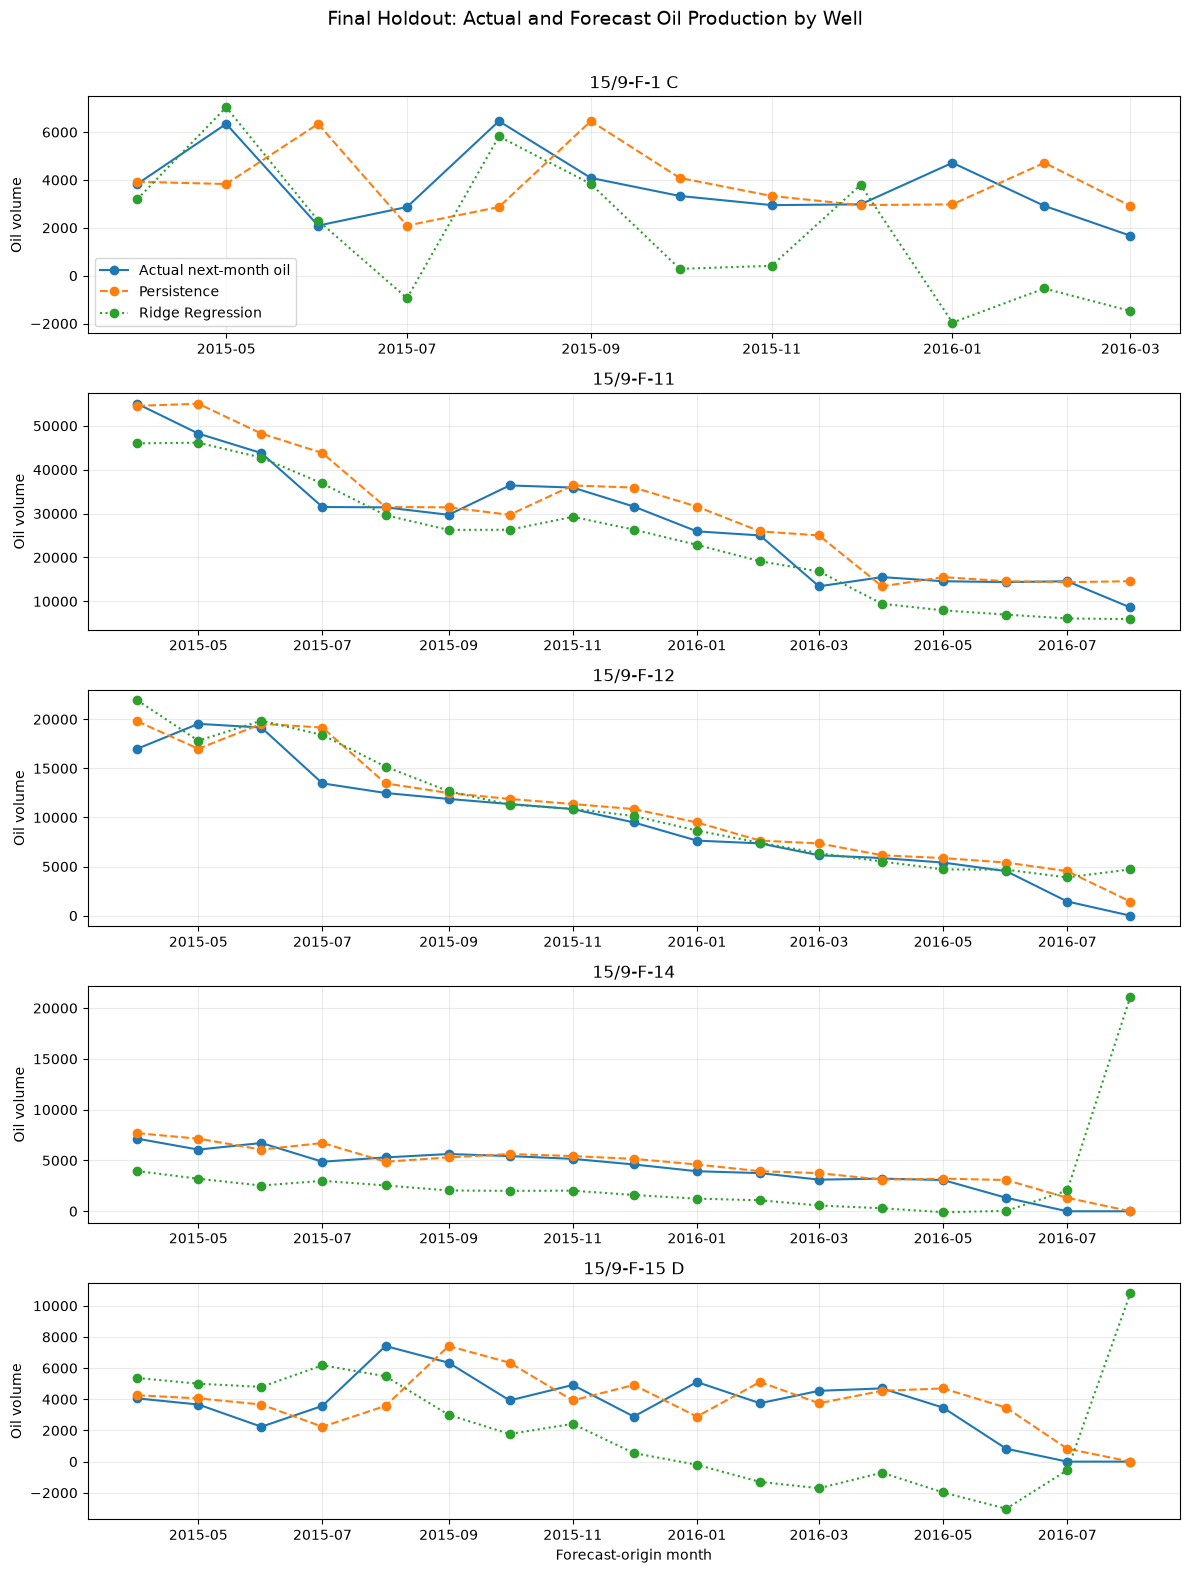

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\figure_12_1_final_holdout_forecasts_by_well.png


In [73]:
holdout_wells = sorted(
    final_holdout_predictions_df[
        "NPD_WELL_BORE_NAME"
    ].unique()
)


fig, axes = plt.subplots(
    nrows=len(holdout_wells),
    ncols=1,
    figsize=(12, 16),
    sharex=False
)


for ax, well_name in zip(
    axes,
    holdout_wells
):

    well_plot_df = (
        final_holdout_predictions_df[
            final_holdout_predictions_df[
                "NPD_WELL_BORE_NAME"
            ]
            ==
            well_name
        ]
        .sort_values(
            "DATE"
        )
    )


    ax.plot(
        well_plot_df["DATE"],
        well_plot_df[
            target_column
        ],
        marker="o",
        label="Actual next-month oil"
    )


    ax.plot(
        well_plot_df["DATE"],
        well_plot_df[
            "persistence_prediction"
        ],
        marker="o",
        linestyle="--",
        label="Persistence"
    )


    ax.plot(
        well_plot_df["DATE"],
        well_plot_df[
            "ridge_prediction"
        ],
        marker="o",
        linestyle=":",
        label="Ridge Regression"
    )


    ax.set_title(
        well_name
    )

    ax.set_ylabel(
        "Oil volume"
    )

    ax.grid(
        alpha=0.25
    )


axes[0].legend(
    loc="best"
)


axes[-1].set_xlabel(
    "Forecast-origin month"
)


fig.suptitle(
    "Final Holdout: Actual and Forecast Oil Production by Well",
    fontsize=14
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.97
    ]
)


figure_12_1_path = (
    MODEL_OUTPUT_DIR
    /
    "figure_12_1_final_holdout_forecasts_by_well.png"
)


plt.savefig(
    figure_12_1_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    figure_12_1_path
)

### 12.2 Final Holdout WAPE by Well

Well-level Weighted Absolute Percentage Error (WAPE) is visualized for the persistence benchmark and selected Ridge Regression model.

Because producer wells operate at different production scales, WAPE provides a normalized comparison of forecasting error across wells.

The figure highlights whether the pooled holdout result is consistently reflected at producer-well level.

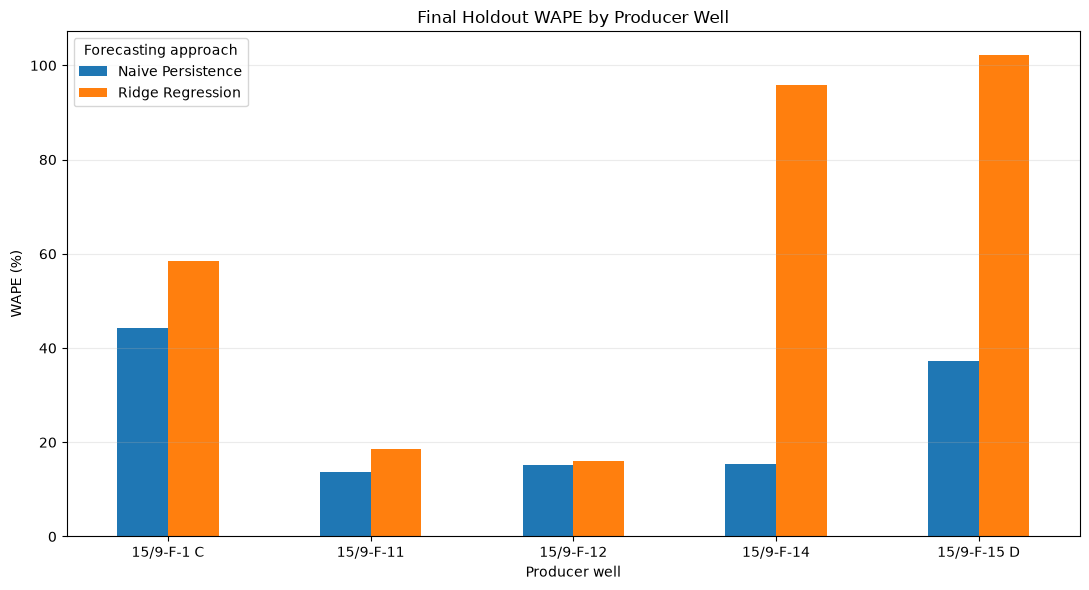

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\figure_12_2_final_holdout_wape_by_well.png


In [74]:
holdout_wape_plot_df = (
    final_holdout_well_summary[
        [
            "well",
            "model",
            "WAPE_pct"
        ]
    ]
    .pivot(
        index="well",
        columns="model",
        values="WAPE_pct"
    )
)


ax = (
    holdout_wape_plot_df[
        [
            "Naive Persistence",
            "Ridge Regression"
        ]
    ]
    .plot(
        kind="bar",
        figsize=(11, 6)
    )
)


ax.set_title(
    "Final Holdout WAPE by Producer Well"
)

ax.set_xlabel(
    "Producer well"
)

ax.set_ylabel(
    "WAPE (%)"
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.25
)


plt.legend(
    title="Forecasting approach"
)

plt.tight_layout()


figure_12_2_path = (
    MODEL_OUTPUT_DIR
    /
    "figure_12_2_final_holdout_wape_by_well.png"
)


plt.savefig(
    figure_12_2_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    figure_12_2_path
)

### 12.3 Ridge RMSE Change Relative to Persistence

The relative RMSE of Ridge Regression against persistence is visualized across the two evaluation stages.

A value below zero indicates that Ridge Regression reduced RMSE relative to persistence, while a value above zero indicates that Ridge Regression produced greater RMSE.

The figure therefore summarizes the change from a modest development-validation advantage to substantially weaker final holdout performance.

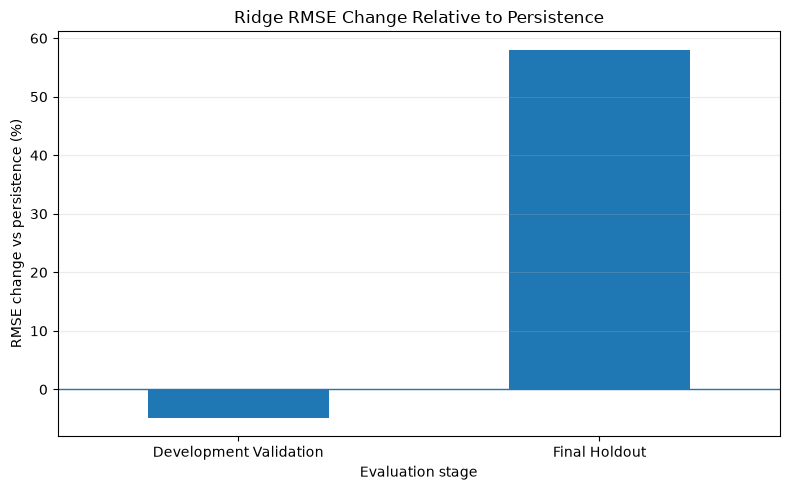

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\figure_12_3_ridge_rmse_generalization_shift.png


In [75]:
rmse_generalization_plot = (
    ridge_vs_persistence_stage_summary[
        [
            "stage",
            "Ridge_RMSE_change_vs_persistence_pct"
        ]
    ]
    .copy()
)


ax = rmse_generalization_plot.plot(
    x="stage",
    y="Ridge_RMSE_change_vs_persistence_pct",
    kind="bar",
    figsize=(8, 5),
    legend=False
)


ax.axhline(
    y=0,
    linewidth=1
)


ax.set_title(
    "Ridge RMSE Change Relative to Persistence"
)

ax.set_xlabel(
    "Evaluation stage"
)

ax.set_ylabel(
    "RMSE change vs persistence (%)"
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


figure_12_3_path = (
    MODEL_OUTPUT_DIR
    /
    "figure_12_3_ridge_rmse_generalization_shift.png"
)


plt.savefig(
    figure_12_3_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    figure_12_3_path
)

### 12.4 Visualization Summary

The final diagnostic figures reinforce the numerical evaluation.

Persistence generally follows the observed short-term production trajectory more closely during the final holdout, while Ridge Regression exhibits larger deviations for several late-life producer histories.

The well-level WAPE comparison confirms that persistence achieved lower normalized error for all five core producers.

The development-to-holdout comparison further shows that Ridge Regression moved from a modest RMSE advantage during temporal validation to substantially higher RMSE during the independent final holdout.

These visualizations therefore support the same conclusion as the numerical analysis without introducing any additional model-selection decisions.

## 13. Export Final Modelling Artifacts

The final modelling results are exported so that subsequent project stages can reproduce the evaluation without rerunning every development experiment.

The locked Ridge Regression pipeline is also saved as the final trained machine-learning artifact.

Saving the Ridge pipeline does not alter the final evaluation conclusion. Naive persistence achieved the strongest observed performance on the independent holdout and remains the primary reference for practical forecasting comparisons.

In [76]:
import json
import joblib


FINAL_MODEL_DIR = (
    PROJECT_ROOT
    /
    "models"
)


FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Final model directory:",
    FINAL_MODEL_DIR
)

Final model directory: F:\DataScience_Projects\Volve_Oil_Production\models


In [77]:
final_export_files = {
    "final_holdout_predictions.csv":
        final_holdout_predictions_df,

    "final_holdout_pooled_metrics.csv":
        final_holdout_pooled_summary,

    "final_holdout_well_metrics.csv":
        final_holdout_well_summary,

    "development_holdout_comparison.csv":
        development_holdout_comparison,

    "ridge_vs_persistence_generalization.csv":
        ridge_vs_persistence_stage_summary,

    "largest_final_ridge_errors.csv":
        largest_final_ridge_errors,

    "final_development_candidate_metrics.csv":
        final_candidate_pooled_summary
}


for file_name, dataframe in (
    final_export_files.items()
):

    output_path = (
        MODEL_OUTPUT_DIR
        /
        file_name
    )

    dataframe.to_csv(
        output_path,
        index=False
    )

    print(
        "Saved:",
        output_path
    )

Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\final_holdout_predictions.csv
Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\final_holdout_pooled_metrics.csv
Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\final_holdout_well_metrics.csv
Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\development_holdout_comparison.csv
Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\ridge_vs_persistence_generalization.csv
Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\largest_final_ridge_errors.csv
Saved: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\final_development_candidate_metrics.csv


### 13.1 Locked Ridge Pipeline

The Ridge Regression pipeline fitted to all 215 development observations is saved for reproducibility and later demonstration.

The serialized object contains both preprocessing and regression stages, ensuring that the same transformations used during final model training are retained with the estimator.

In [78]:
final_ridge_model_path = (
    FINAL_MODEL_DIR
    /
    "ridge_next_month_oil_forecast_pipeline.joblib"
)


joblib.dump(
    final_ridge_pipeline,
    final_ridge_model_path
)


print(
    "Saved final Ridge pipeline:",
    final_ridge_model_path
)

print(
    "Model file exists:",
    final_ridge_model_path.exists()
)

print(
    "Model file size:",
    final_ridge_model_path.stat().st_size,
    "bytes"
)

Saved final Ridge pipeline: F:\DataScience_Projects\Volve_Oil_Production\models\ridge_next_month_oil_forecast_pipeline.joblib
Model file exists: True
Model file size: 5274 bytes


### 13.2 Final Modelling Manifest

A small machine-readable manifest records the forecasting task, locked model configuration, feature structure, chronological split, and principal final evaluation result.

This provides a concise reproducibility record for later application and documentation stages.

In [79]:
final_model_manifest = {

    "forecasting_task":
        (
            "Predict next-month oil production volume "
            "for the same producer well."
        ),

    "forecast_horizon":
        "one month ahead",

    "selected_trainable_model":
        "Ridge Regression",

    "ridge_alpha":
        10.0,

    "selected_feature_set":
        "Core",

    "numeric_features":
        list(
            FINAL_NUMERIC_FEATURES
        ),

    "categorical_features":
        list(
            categorical_features
        ),

    "target":
        target_column,

    "development_observations":
        int(
            len(development_df)
        ),

    "development_end":
        str(
            development_df[
                "DATE"
            ].max().date()
        ),

    "final_holdout_start":
        str(
            final_holdout_df[
                "DATE"
            ].min().date()
        ),

    "final_holdout_end":
        str(
            final_holdout_df[
                "DATE"
            ].max().date()
        ),

    "final_holdout_observations":
        int(
            len(final_holdout_df)
        ),

    "final_holdout_best_observed_method":
        "Naive Persistence",

    "ridge_holdout_negative_predictions":
        int(
            (
                final_holdout_predictions_df[
                    "ridge_prediction"
                ]
                < 0
            ).sum()
        ),

    "post_holdout_retuning_performed":
        False,

    "scikit_learn_version":
        sklearn.__version__,

    "scipy_version":
        scipy.__version__
}


manifest_path = (
    MODEL_OUTPUT_DIR
    /
    "final_model_manifest.json"
)


with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_model_manifest,
        file,
        indent=4
    )


print(
    "Saved modelling manifest:",
    manifest_path
)


display(
    pd.Series(
        final_model_manifest,
        name="value"
    )
)

Saved modelling manifest: F:\DataScience_Projects\Volve_Oil_Production\outputs\03_model_development\final_model_manifest.json


forecasting_task                      Predict next-month oil production volume for t...
forecast_horizon                                                        one month ahead
selected_trainable_model                                               Ridge Regression
ridge_alpha                                                                        10.0
selected_feature_set                                                               Core
numeric_features                      [oil_volume, production_age_months, oil_per_on...
categorical_features                                               [NPD_WELL_BORE_NAME]
target                                                     target_next_month_oil_volume
development_observations                                                            215
development_end                                                              2015-03-01
final_holdout_start                                                          2015-04-01
final_holdout_end               

### 13.3 Final Artifact Verification

The exported modelling artifacts are checked before the notebook is closed to confirm that the final tables, diagnostic figures, modelling manifest, and serialized Ridge pipeline were successfully created.

In [81]:
required_final_artifacts = [

    MODEL_OUTPUT_DIR
    /
    "final_holdout_predictions.csv",

    MODEL_OUTPUT_DIR
    /
    "final_holdout_pooled_metrics.csv",

    MODEL_OUTPUT_DIR
    /
    "final_holdout_well_metrics.csv",

    MODEL_OUTPUT_DIR
    /
    "development_holdout_comparison.csv",

    MODEL_OUTPUT_DIR
    /
    "ridge_vs_persistence_generalization.csv",

    MODEL_OUTPUT_DIR
    /
    "largest_final_ridge_errors.csv",

    MODEL_OUTPUT_DIR
    /
    "final_development_candidate_metrics.csv",

    MODEL_OUTPUT_DIR
    /
    "final_model_manifest.json",

    MODEL_OUTPUT_DIR
    /
    "figure_12_1_final_holdout_forecasts_by_well.png",

    MODEL_OUTPUT_DIR
    /
    "figure_12_2_final_holdout_wape_by_well.png",

    MODEL_OUTPUT_DIR
    /
    "figure_12_3_ridge_rmse_generalization_shift.png",

    final_ridge_model_path
]


artifact_check = pd.DataFrame({

    "artifact":
        [
            path.name
            for path
            in required_final_artifacts
        ],

    "exists":
        [
            path.exists()
            for path
            in required_final_artifacts
        ],

    "size_bytes":
        [
            (
                path.stat().st_size
                if path.exists()
                else np.nan
            )
            for path
            in required_final_artifacts
        ]
})


display(
    artifact_check
)


assert (
    artifact_check[
        "exists"
    ]
    .all()
)


print(
    "\nPASS: all final Notebook 03 "
    "artifacts exist."
)

print(
    "Notebook 03 modelling workflow complete."
)

,artifact,exists,size_bytes
0,final_holdout_predictions.csv,True,5323
1,final_holdout_pooled_metrics.csv,True,225
2,final_holdout_well_metrics.csv,True,1154
3,development_holdout_comparison.csv,True,523
4,ridge_vs_persistence_generalization.csv,True,329
5,largest_final_ridge_errors.csv,True,1327
6,final_development_candidate_metrics.csv,True,451
7,final_model_manifest.json,True,1131
8,figure_12_1_final_holdout_forecasts_by_well.png,True,937135
9,figure_12_2_final_holdout_wape_by_well.png,True,112605



PASS: all final Notebook 03 artifacts exist.
Notebook 03 modelling workflow complete.


## 14. Notebook 03 Final Conclusions

Notebook 03 developed and evaluated one-month-ahead oil-production forecasting approaches for the core Volve producer wells using the modelling dataset prepared in Notebook 02.

The modelling process began with naive persistence and progressed through Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting. Model development used chronological expanding-window validation rather than random splitting, and all preprocessing operations were fitted within the corresponding training periods.

Controlled feature-set analysis showed that the compact Core feature structure provided the most defensible overall representation. Additional operational lags and historical rolling variables did not produce sufficiently consistent improvements to justify their additional complexity.

Among the trainable models, Ridge Regression with alpha = 10 produced the strongest development-stage pooled RMSE and R² and the most stable RMSE across the two temporal validation folds. It was therefore locked as the final trained machine-learning model before the independent holdout was evaluated.

The independent April-2015-onward holdout produced a different result. Naive persistence achieved lower MAE, RMSE, and WAPE and higher pooled R² than Ridge Regression. Persistence also achieved lower MAE, RMSE, and WAPE for every one of the five core producer wells.

Ridge Regression additionally generated 12 physically implausible negative holdout forecasts and produced particularly large errors for some late-life and zero-production observations. No clipping, model switching, feature modification, or post-holdout retuning was performed after observing these results.

The project therefore finds that the selected machine-learning model did not provide a forecasting advantage over the strong month-to-month persistence benchmark during the final unseen period. The result demonstrates the importance of chronological validation, simple forecasting baselines, well-level evaluation, and genuinely independent future-period testing.

The final Ridge pipeline and supporting evaluation tables have been retained as reproducible modelling artifacts, while naive persistence represents the strongest observed out-of-sample forecasting approach in the completed evaluation.

Notebook 03 is therefore complete. Subsequent project stages can use these frozen modelling results for application development, reporting, interpretation, and portfolio presentation without reopening model selection.